# **IMPORT LIBRARY**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# **BAB I Data Cleaning dan Filling**

## 1.1 Ekstraksi Dataset 

In [3]:
df=pd.read_excel('NYC TLC Trip Record.xlsx') # membaca file di python
df.head() # memperlihatkan kolom dan 5 rows pertama

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.9,1.0,0.5,4.03,0.0,NaN,1.0,24.18,1.0,1.0,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.7,1.0,0.5,2.64,0.0,NaN,1.0,15.84,1.0,1.0,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.2,1.0,0.5,1.94,0.0,NaN,1.0,11.64,1.0,1.0,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.5,0.5,1.5,1.70,0.0,NaN,1.0,10.20,1.0,1.0,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.0,0.5,1.5,0.00,0.0,NaN,1.0,8.00,1.0,1.0,0.00


In [4]:
df.info() #melihat kolom yang null


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68211 entries, 0 to 68210
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               68211 non-null  int64         
 1   lpep_pickup_datetime   68211 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  68211 non-null  datetime64[ns]
 3   store_and_fwd_flag     63887 non-null  object        
 4   RatecodeID             63887 non-null  float64       
 5   PULocationID           68211 non-null  int64         
 6   DOLocationID           68211 non-null  int64         
 7   passenger_count        63887 non-null  float64       
 8   trip_distance          68211 non-null  float64       
 9   fare_amount            68211 non-null  float64       
 10  extra                  68211 non-null  float64       
 11  mta_tax                68211 non-null  float64       
 12  tip_amount             68211 non-null  float64       
 13  t

In [5]:
df.drop('ehail_fee', axis=1, inplace=True) #membuang kolom ehail_fee karena semua null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68211 entries, 0 to 68210
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               68211 non-null  int64         
 1   lpep_pickup_datetime   68211 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  68211 non-null  datetime64[ns]
 3   store_and_fwd_flag     63887 non-null  object        
 4   RatecodeID             63887 non-null  float64       
 5   PULocationID           68211 non-null  int64         
 6   DOLocationID           68211 non-null  int64         
 7   passenger_count        63887 non-null  float64       
 8   trip_distance          68211 non-null  float64       
 9   fare_amount            68211 non-null  float64       
 10  extra                  68211 non-null  float64       
 11  mta_tax                68211 non-null  float64       
 12  tip_amount             68211 non-null  float64       
 13  t

## 1.2 Melihat kolom dengan total_amount minus (Tidak Jadi Naik Taxi)

In [6]:
df_fare_minus = df.loc[df['total_amount']<=0, : ] # melihat kolom dengan total_amount minus (error)
df['flag_cancel'] = df['total_amount'] <= 0 
df['flag_cancel'].value_counts()

flag_cancel
False    67963
True       248
Name: count, dtype: int64

1.2.1 Membuat kolom unik baru dari suatu perjalanan, fungsinya adalah untuk menghapus transaksi yang cancel, karena unique_code akan sama ketika nilai negatif dilakukan pengembalian

In [7]:
df['unique_code'] = (
    df['VendorID'].astype(str) + '_' +
    df['lpep_pickup_datetime'].astype(str) + '_' +
    df['lpep_dropoff_datetime'].astype(str) + '_' +
    df['PULocationID'].astype(str) + '_' +
    df['DOLocationID'].astype(str) + '_' +
    df['payment_type'].astype(str) + '_' +
    df['trip_type'].astype(str)
)
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,flag_cancel,unique_code
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.9,...,0.5,4.03,0.0,1.0,24.18,1.0,1.0,2.75,False,2_2023-01-01 00:26:10_2023-01-01 00:37:11_166_...
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.7,...,0.5,2.64,0.0,1.0,15.84,1.0,1.0,0.00,False,2_2023-01-01 00:51:03_2023-01-01 00:57:49_24_4...
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.2,...,0.5,1.94,0.0,1.0,11.64,1.0,1.0,0.00,False,2_2023-01-01 00:35:12_2023-01-01 00:41:32_223_...
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.5,...,1.5,1.70,0.0,1.0,10.20,1.0,1.0,0.00,False,1_2023-01-01 00:13:14_2023-01-01 00:19:03_41_2...
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.0,...,1.5,0.00,0.0,1.0,8.00,1.0,1.0,0.00,False,1_2023-01-01 00:33:04_2023-01-01 00:39:02_41_7...


1.2.2 Setelah unique code jadi menghapus pasangan row untuk transaksi tidak jadi, dimana unique code nya akan sama, kemudia filtrasi yang memiliki amount lebih besar dari 0

In [8]:
df.drop_duplicates(subset='unique_code', keep=False, inplace=True) #total ada 348 row yang dihapus, pasangan transaksi dibatalkan
df = df[df['total_amount'] >= 0] #ini menghapus yang memang error dimana total_amount<0
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67858 entries, 0 to 68210
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67858 non-null  int64         
 1   lpep_pickup_datetime   67858 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67858 non-null  datetime64[ns]
 3   store_and_fwd_flag     63539 non-null  object        
 4   RatecodeID             63539 non-null  float64       
 5   PULocationID           67858 non-null  int64         
 6   DOLocationID           67858 non-null  int64         
 7   passenger_count        63539 non-null  float64       
 8   trip_distance          67858 non-null  float64       
 9   fare_amount            67858 non-null  float64       
 10  extra                  67858 non-null  float64       
 11  mta_tax                67858 non-null  float64       
 12  tip_amount             67858 non-null  float64       
 13  tolls_

In [9]:
df.info()
df.sort_values(by='lpep_pickup_datetime').head()

<class 'pandas.core.frame.DataFrame'>
Index: 67858 entries, 0 to 68210
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67858 non-null  int64         
 1   lpep_pickup_datetime   67858 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67858 non-null  datetime64[ns]
 3   store_and_fwd_flag     63539 non-null  object        
 4   RatecodeID             63539 non-null  float64       
 5   PULocationID           67858 non-null  int64         
 6   DOLocationID           67858 non-null  int64         
 7   passenger_count        63539 non-null  float64       
 8   trip_distance          67858 non-null  float64       
 9   fare_amount            67858 non-null  float64       
 10  extra                  67858 non-null  float64       
 11  mta_tax                67858 non-null  float64       
 12  tip_amount             67858 non-null  float64       
 13  tolls_

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,flag_cancel,unique_code
17874,2,2009-01-01 20:21:27,2009-01-02 11:07:31,N,1.0,65,178,1.0,7.72,34.5,...,0.5,7.20,0.00,1.0,43.20,1.0,1.0,0.00,False,2_2009-01-01 20:21:27_2009-01-02 11:07:31_65_1...
298,2,2022-12-09 14:10:49,2022-12-09 14:22:26,N,1.0,7,56,1.0,5.37,16.0,...,0.5,0.00,0.00,0.3,16.80,2.0,1.0,0.00,False,2_2022-12-09 14:10:49_2022-12-09 14:22:26_7_56...
318,2,2022-12-09 14:55:42,2022-12-09 15:33:06,N,1.0,260,164,1.0,5.48,25.5,...,0.5,0.00,6.55,0.3,35.60,2.0,1.0,2.75,False,2_2022-12-09 14:55:42_2022-12-09 15:33:06_260_...
24,2,2023-01-01 00:01:31,2023-01-01 00:16:02,N,1.0,166,244,1.0,2.48,16.3,...,0.5,3.76,0.00,1.0,22.56,1.0,1.0,0.00,False,2_2023-01-01 00:01:31_2023-01-01 00:16:02_166_...
44,2,2023-01-01 00:04:25,2023-01-01 00:17:50,N,1.0,255,146,1.0,2.80,16.3,...,0.5,2.80,0.00,1.0,21.60,1.0,1.0,0.00,False,2_2023-01-01 00:04:25_2023-01-01 00:17:50_255_...


## 1.3 Outlier Cleaning dan Data Filling

1.3.1 menghapus outlier waktu (transaksi tahun 2009)

In [10]:
df.drop(index=17874,inplace=True) #hapus index 17874 dimana waktunya error di tahun 2009
df.sort_values(by='lpep_pickup_datetime')

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,flag_cancel,unique_code
298,2,2022-12-09 14:10:49,2022-12-09 14:22:26,N,1.0,7,56,1.0,5.37,16.00,...,0.5,0.00,0.00,0.3,16.80,2.0,1.0,0.00,False,2_2022-12-09 14:10:49_2022-12-09 14:22:26_7_56...
318,2,2022-12-09 14:55:42,2022-12-09 15:33:06,N,1.0,260,164,1.0,5.48,25.50,...,0.5,0.00,6.55,0.3,35.60,2.0,1.0,2.75,False,2_2022-12-09 14:55:42_2022-12-09 15:33:06_260_...
24,2,2023-01-01 00:01:31,2023-01-01 00:16:02,N,1.0,166,244,1.0,2.48,16.30,...,0.5,3.76,0.00,1.0,22.56,1.0,1.0,0.00,False,2_2023-01-01 00:01:31_2023-01-01 00:16:02_166_...
44,2,2023-01-01 00:04:25,2023-01-01 00:17:50,N,1.0,255,146,1.0,2.80,16.30,...,0.5,2.80,0.00,1.0,21.60,1.0,1.0,0.00,False,2_2023-01-01 00:04:25_2023-01-01 00:17:50_255_...
57,2,2023-01-01 00:06:48,2023-01-01 01:08:47,N,1.0,129,226,2.0,7.83,52.00,...,0.5,0.00,0.00,1.0,54.50,2.0,1.0,0.00,False,2_2023-01-01 00:06:48_2023-01-01 01:08:47_129_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68210,2,2023-01-31 23:51:00,2023-02-01 00:07:00,NaN,NaN,256,140,NaN,5.82,23.65,...,0.0,2.00,0.00,1.0,29.40,NaN,NaN,NaN,False,2_2023-01-31 23:51:00_2023-02-01 00:07:00_256_...
63876,2,2023-01-31 23:53:41,2023-02-01 00:31:14,N,1.0,82,83,2.0,6.44,38.00,...,0.5,0.00,0.00,1.0,40.50,2.0,1.0,0.00,False,2_2023-01-31 23:53:41_2023-02-01 00:31:14_82_8...
63858,2,2023-01-31 23:56:16,2023-02-01 00:03:16,N,1.0,95,196,1.0,1.16,8.60,...,0.5,2.22,0.00,1.0,13.32,1.0,1.0,0.00,False,2_2023-01-31 23:56:16_2023-02-01 00:03:16_95_1...
63872,2,2023-01-31 23:58:23,2023-02-01 00:07:16,N,1.0,95,135,1.0,1.39,10.70,...,0.5,2.64,0.00,1.0,15.84,1.0,1.0,0.00,False,2_2023-01-31 23:58:23_2023-02-01 00:07:16_95_1...


1.3.2 Filling Data store_and_fwd_flag mengisi data kosong dengan modus 

In [11]:
display(df['store_and_fwd_flag'].value_counts()) #modus nya adalah N
df['store_and_fwd_flag']=df['store_and_fwd_flag'].fillna('N')
df.info()

store_and_fwd_flag
N    63230
Y      308
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
Index: 67857 entries, 0 to 68210
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67857 non-null  int64         
 1   lpep_pickup_datetime   67857 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67857 non-null  datetime64[ns]
 3   store_and_fwd_flag     67857 non-null  object        
 4   RatecodeID             63538 non-null  float64       
 5   PULocationID           67857 non-null  int64         
 6   DOLocationID           67857 non-null  int64         
 7   passenger_count        63538 non-null  float64       
 8   trip_distance          67857 non-null  float64       
 9   fare_amount            67857 non-null  float64       
 10  extra                  67857 non-null  float64       
 11  mta_tax                67857 non-null  float64       
 12  tip_amount             67857 non-null  float64       
 13  tolls_

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67857 entries, 0 to 68210
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67857 non-null  int64         
 1   lpep_pickup_datetime   67857 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67857 non-null  datetime64[ns]
 3   store_and_fwd_flag     67857 non-null  object        
 4   RatecodeID             63538 non-null  float64       
 5   PULocationID           67857 non-null  int64         
 6   DOLocationID           67857 non-null  int64         
 7   passenger_count        63538 non-null  float64       
 8   trip_distance          67857 non-null  float64       
 9   fare_amount            67857 non-null  float64       
 10  extra                  67857 non-null  float64       
 11  mta_tax                67857 non-null  float64       
 12  tip_amount             67857 non-null  float64       
 13  tolls_

1.3.3 Membuat kolom baru dari RatecodeID

In [13]:
df['RateCode_desc'] = df['RatecodeID'].map({
    1: 'Standard rate',
    2: 'JFK',
    3: 'Newark',
    4: 'Nassau/Westchester',
    5: 'Negotiated fare',
    6: 'Group ride',
    99: 'Error'
}).fillna('Unknown') #mendeskripsikan kolom RatecodeID
df['RateCode_desc'].value_counts()

RateCode_desc
Standard rate         61776
Unknown                4319
Negotiated fare        1511
JFK                     154
Nassau/Westchester       57
Newark                   30
Error                    10
Name: count, dtype: int64

1.3.4 Menghapus row dengan RateCode_desc yang memiliki value error

In [14]:
#menghapus yang RatecodeID dengan flag Error
df = df.drop(df[df['RateCode_desc'] == 'Error'].index)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67847 entries, 0 to 68210
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67847 non-null  int64         
 1   lpep_pickup_datetime   67847 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67847 non-null  datetime64[ns]
 3   store_and_fwd_flag     67847 non-null  object        
 4   RatecodeID             63528 non-null  float64       
 5   PULocationID           67847 non-null  int64         
 6   DOLocationID           67847 non-null  int64         
 7   passenger_count        63528 non-null  float64       
 8   trip_distance          67847 non-null  float64       
 9   fare_amount            67847 non-null  float64       
 10  extra                  67847 non-null  float64       
 11  mta_tax                67847 non-null  float64       
 12  tip_amount             67847 non-null  float64       
 13  tolls_

1.3.5 mengisi RatecodeID dengan modus 1/Standard Rate

In [15]:
#mengisi RateCodeID dengan nilai modusnya yaitu '1/Standard Rate'
df['RatecodeID']=df['RatecodeID'].fillna('1')
df['RatecodeID'] = df['RatecodeID'].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67847 entries, 0 to 68210
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67847 non-null  int64         
 1   lpep_pickup_datetime   67847 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67847 non-null  datetime64[ns]
 3   store_and_fwd_flag     67847 non-null  object        
 4   RatecodeID             67847 non-null  float64       
 5   PULocationID           67847 non-null  int64         
 6   DOLocationID           67847 non-null  int64         
 7   passenger_count        63528 non-null  float64       
 8   trip_distance          67847 non-null  float64       
 9   fare_amount            67847 non-null  float64       
 10  extra                  67847 non-null  float64       
 11  mta_tax                67847 non-null  float64       
 12  tip_amount             67847 non-null  float64       
 13  tolls_

1.3.6 Menghapus passenger count = 0

In [16]:
df = df[df['passenger_count'] != 0] #menghapus passenger_count dengan nilai 0
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67511 entries, 0 to 68210
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67511 non-null  int64         
 1   lpep_pickup_datetime   67511 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67511 non-null  datetime64[ns]
 3   store_and_fwd_flag     67511 non-null  object        
 4   RatecodeID             67511 non-null  float64       
 5   PULocationID           67511 non-null  int64         
 6   DOLocationID           67511 non-null  int64         
 7   passenger_count        63192 non-null  float64       
 8   trip_distance          67511 non-null  float64       
 9   fare_amount            67511 non-null  float64       
 10  extra                  67511 non-null  float64       
 11  mta_tax                67511 non-null  float64       
 12  tip_amount             67511 non-null  float64       
 13  tolls_

1.3.6 Melihat distribusi passenger count dan diisi dengan median dan hapus outlier

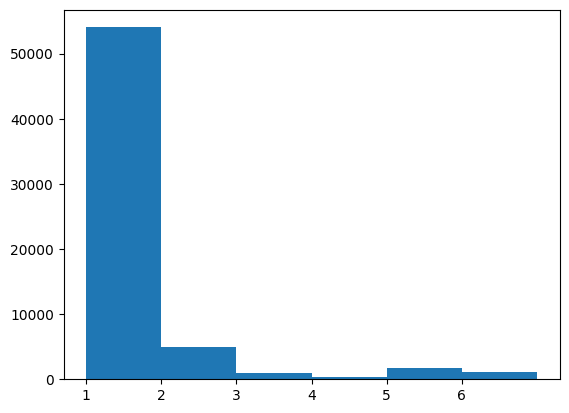

In [17]:
#melihat kolom passenger_count terdistribusi normal atau tidak, untuk menentukan data kosong diisi dengan mean atau median

plt.hist(df['passenger_count'], bins=range(1,8))
plt.xticks(range(1,7))
plt.show()

#data tidak terdistribusi normal sehingga data kosong diisi menggunakan median

In [18]:
#mengisi data passenger_count menggunakan median
display(df['passenger_count'].median())
df['passenger_count']=df['passenger_count'].fillna(1) #diisi menggunakan median
df['passenger_count']=df['passenger_count'].astype(int) #mengubah tipe data tadinya float menjadi integer
df['passenger_count'].value_counts()

np.float64(1.0)

passenger_count
1    58357
2     5026
5     1764
6     1052
3      944
4      360
7        4
9        2
8        2
Name: count, dtype: int64

In [19]:
#menghapus yang penumpang yang diatas 6 karena taxi maksimal 6 orang dan data hanya ada 8 rows(lebih baik dihapus)
df = df[df['passenger_count'] <= 6]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67503 entries, 0 to 68210
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67503 non-null  int64         
 1   lpep_pickup_datetime   67503 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67503 non-null  datetime64[ns]
 3   store_and_fwd_flag     67503 non-null  object        
 4   RatecodeID             67503 non-null  float64       
 5   PULocationID           67503 non-null  int64         
 6   DOLocationID           67503 non-null  int64         
 7   passenger_count        67503 non-null  int64         
 8   trip_distance          67503 non-null  float64       
 9   fare_amount            67503 non-null  float64       
 10  extra                  67503 non-null  float64       
 11  mta_tax                67503 non-null  float64       
 12  tip_amount             67503 non-null  float64       
 13  tolls_

1.3.8 menghapus trip distance 0 dengan total amount 0

In [20]:
#menghapus trip_distance = 0 dan total_amount = 0 juga tandanya trip nya error
df = df[~((df['trip_distance'] == 0) & (df['total_amount'] == 0))]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67443 entries, 0 to 68210
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67443 non-null  int64         
 1   lpep_pickup_datetime   67443 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67443 non-null  datetime64[ns]
 3   store_and_fwd_flag     67443 non-null  object        
 4   RatecodeID             67443 non-null  float64       
 5   PULocationID           67443 non-null  int64         
 6   DOLocationID           67443 non-null  int64         
 7   passenger_count        67443 non-null  int64         
 8   trip_distance          67443 non-null  float64       
 9   fare_amount            67443 non-null  float64       
 10  extra                  67443 non-null  float64       
 11  mta_tax                67443 non-null  float64       
 12  tip_amount             67443 non-null  float64       
 13  tolls_

In [21]:
#memberi notes trip_distance = 0 namun total_amount > 0 sebagai trip tidak terecord, dan selain itu adalah trip terecord
df['trip_status'] = 'trip terecord'

df.loc[(df['trip_distance'] == 0) & (df['total_amount'] > 0), 'trip_status'] = 'trip tidak terecord'

display(df['trip_status'].value_counts())
df.info()

trip_status
trip terecord          64334
trip tidak terecord     3109
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
Index: 67443 entries, 0 to 68210
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67443 non-null  int64         
 1   lpep_pickup_datetime   67443 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67443 non-null  datetime64[ns]
 3   store_and_fwd_flag     67443 non-null  object        
 4   RatecodeID             67443 non-null  float64       
 5   PULocationID           67443 non-null  int64         
 6   DOLocationID           67443 non-null  int64         
 7   passenger_count        67443 non-null  int64         
 8   trip_distance          67443 non-null  float64       
 9   fare_amount            67443 non-null  float64       
 10  extra                  67443 non-null  float64       
 11  mta_tax                67443 non-null  float64       
 12  tip_amount             67443 non-null  float64       
 13  tolls_

1.3.9 Menghapus fare amount anomali

In [22]:
#menghapus fare_amount yang anomali (kurang atau sama dengan 0)
df=df.loc[df['fare_amount']!=0, : ]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67427 entries, 0 to 68210
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67427 non-null  int64         
 1   lpep_pickup_datetime   67427 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67427 non-null  datetime64[ns]
 3   store_and_fwd_flag     67427 non-null  object        
 4   RatecodeID             67427 non-null  float64       
 5   PULocationID           67427 non-null  int64         
 6   DOLocationID           67427 non-null  int64         
 7   passenger_count        67427 non-null  int64         
 8   trip_distance          67427 non-null  float64       
 9   fare_amount            67427 non-null  float64       
 10  extra                  67427 non-null  float64       
 11  mta_tax                67427 non-null  float64       
 12  tip_amount             67427 non-null  float64       
 13  tolls_

1.3.10 mengisi payment_type_desc dengan modus nya

In [23]:
#mengisi payment type menggunakan modus karena merupakan data kategorikal nominal
df['payment_type_desc'] = df['payment_type'].map({
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown'
})
#modusnya adalah 1 atau kredit card
df['payment_type'].value_counts()

payment_type
1.0    40402
2.0    22494
3.0      181
4.0       29
5.0        2
Name: count, dtype: int64

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67427 entries, 0 to 68210
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67427 non-null  int64         
 1   lpep_pickup_datetime   67427 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67427 non-null  datetime64[ns]
 3   store_and_fwd_flag     67427 non-null  object        
 4   RatecodeID             67427 non-null  float64       
 5   PULocationID           67427 non-null  int64         
 6   DOLocationID           67427 non-null  int64         
 7   passenger_count        67427 non-null  int64         
 8   trip_distance          67427 non-null  float64       
 9   fare_amount            67427 non-null  float64       
 10  extra                  67427 non-null  float64       
 11  mta_tax                67427 non-null  float64       
 12  tip_amount             67427 non-null  float64       
 13  tolls_

In [25]:
df['payment_type'] = df['payment_type'].fillna(1)
df['payment_type_desc'] = df['payment_type'].map({
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown'
})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67427 entries, 0 to 68210
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67427 non-null  int64         
 1   lpep_pickup_datetime   67427 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67427 non-null  datetime64[ns]
 3   store_and_fwd_flag     67427 non-null  object        
 4   RatecodeID             67427 non-null  float64       
 5   PULocationID           67427 non-null  int64         
 6   DOLocationID           67427 non-null  int64         
 7   passenger_count        67427 non-null  int64         
 8   trip_distance          67427 non-null  float64       
 9   fare_amount            67427 non-null  float64       
 10  extra                  67427 non-null  float64       
 11  mta_tax                67427 non-null  float64       
 12  tip_amount             67427 non-null  float64       
 13  tolls_

1.3.11 mengisi trip_type_desc dengan modus (1)

In [26]:
#mapping awal
df['trip_type_desc'] = df['trip_type'].map({
    1: 'Street-hail',
    2: 'Dispatch'
})
#melihat modus trip_type (merupakan data kategorikal nominal)
display(df['trip_type'].value_counts())
df['trip_type']=df['trip_type'].fillna(1)
df.info()
#mapping ulang
df['trip_type_desc'] = df['trip_type'].map({
    1: 'Street-hail',
    2: 'Dispatch'
})

trip_type
1.0    61773
2.0     1335
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
Index: 67427 entries, 0 to 68210
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67427 non-null  int64         
 1   lpep_pickup_datetime   67427 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67427 non-null  datetime64[ns]
 3   store_and_fwd_flag     67427 non-null  object        
 4   RatecodeID             67427 non-null  float64       
 5   PULocationID           67427 non-null  int64         
 6   DOLocationID           67427 non-null  int64         
 7   passenger_count        67427 non-null  int64         
 8   trip_distance          67427 non-null  float64       
 9   fare_amount            67427 non-null  float64       
 10  extra                  67427 non-null  float64       
 11  mta_tax                67427 non-null  float64       
 12  tip_amount             67427 non-null  float64       
 13  tolls_

1.3.12 Mengisi congestion_surcharge dengan median karena tidak terdistribusi normal

congestion_surcharge
0.00    46295
2.75    16797
2.50       16
Name: count, dtype: int64

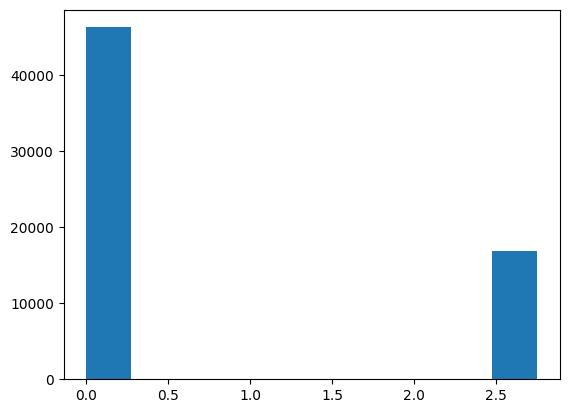

<class 'pandas.core.frame.DataFrame'>
Index: 67427 entries, 0 to 68210
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67427 non-null  int64         
 1   lpep_pickup_datetime   67427 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67427 non-null  datetime64[ns]
 3   store_and_fwd_flag     67427 non-null  object        
 4   RatecodeID             67427 non-null  float64       
 5   PULocationID           67427 non-null  int64         
 6   DOLocationID           67427 non-null  int64         
 7   passenger_count        67427 non-null  int64         
 8   trip_distance          67427 non-null  float64       
 9   fare_amount            67427 non-null  float64       
 10  extra                  67427 non-null  float64       
 11  mta_tax                67427 non-null  float64       
 12  tip_amount             67427 non-null  float64       
 13  tolls_

In [27]:
display(df['congestion_surcharge'].value_counts())
#merupakan data kualitatif kontinu, harus dilihat distribusinya
plt.hist(df['congestion_surcharge'])
plt.show()
#tidak terdistribusi normal, menggunakan median
df['congestion_surcharge'].median() #mediannya adalah 0

df['congestion_surcharge']=df['congestion_surcharge'].fillna(0)
df.info()

## 1.4 Finalisasi Cleaning

1.4.1 membuang kolom yang sudah tidak diperlukan

In [28]:
df.columns
df.drop(columns='unique_code', axis = 1, inplace=True)
df['flag_cancel'].value_counts()
df.drop(columns='flag_cancel', axis=1,inplace=True)
df.drop(columns='trip_status', axis=1,inplace=True)

1.4.2 membuant kolom baru berupa latittude dan longitude untuk choropleth analysis

In [29]:
df_location_detail = pd.read_excel('NYC TLC Trip Record.xlsx', sheet_name = 'Lookup Tabel')
df_location_detail.head()

,LocationID,Borough,Zone,service_zone,lattitude_zone,longitude_zone
0,1,EWR,Newark Airport,EWR,40.6895,-74.1745
1,2,Queens,Jamaica Bay,Boro Zone,40.612,-73.834
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone,40.862,-73.843
3,4,Manhattan,Alphabet City,Yellow Zone,40.7251,-73.9796
4,5,Staten Island,Arden Heights,Boro Zone,40.556,-74.174


1.4.3 menambah kolom nama pickup zone, dropoff zone

In [30]:
# merge dulu
df = df.merge(
    df_location_detail[['LocationID', 'Borough', 'Zone', 'service_zone']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
).drop(columns='LocationID')

# rename biar jelas
df = df.rename(columns={
    'Zone': 'PU_Zone',
    'Borough': 'PU_borough',
    'service_zone': 'PU_service_zone'
})

In [31]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,total_amount,payment_type,trip_type,congestion_surcharge,RateCode_desc,payment_type_desc,trip_type_desc,PU_borough,PU_Zone,PU_service_zone
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1,2.58,14.9,...,24.18,1.0,1.0,2.75,Standard rate,Credit card,Street-hail,Manhattan,Morningside Heights,Boro Zone
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1,1.81,10.7,...,15.84,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Manhattan,Bloomingdale,Yellow Zone
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1,0.00,7.2,...,11.64,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Queens,Steinway,Boro Zone
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1,1.30,6.5,...,10.20,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Manhattan,Central Harlem,Boro Zone
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1,1.10,6.0,...,8.00,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Manhattan,Central Harlem,Boro Zone


In [32]:
df['PU_Zone'].value_counts()

PU_Zone
East Harlem North                13208
East Harlem South                 8991
Central Harlem                    4003
Morningside Heights               3868
Forest Hills                      3818
                                 ...  
West Brighton                        1
Meatpacking/West Village West        1
Lenox Hill West                      1
Midtown South                        1
Country Club                         1
Name: count, Length: 225, dtype: int64

In [33]:
# Merapikan kolom
cols = list(df.columns)

# cari index PULocationID
idx = cols.index('PULocationID')

# kolom yang mau dipindah
new_cols = ['PU_Zone','PU_borough','PU_service_zone']

# hapus dulu dari posisi lama
for col in new_cols:
    cols.remove(col)

# sisipkan setelah PULocationID
for i, col in enumerate(new_cols):
    cols.insert(idx + 1 + i, col)

# apply ke dataframe
df = df[cols]
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,PU_Zone,PU_borough,PU_service_zone,DOLocationID,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,RateCode_desc,payment_type_desc,trip_type_desc
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,Morningside Heights,Manhattan,Boro Zone,143,...,4.03,0.0,1.0,24.18,1.0,1.0,2.75,Standard rate,Credit card,Street-hail
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,Bloomingdale,Manhattan,Yellow Zone,43,...,2.64,0.0,1.0,15.84,1.0,1.0,0.00,Standard rate,Credit card,Street-hail
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,Steinway,Queens,Boro Zone,179,...,1.94,0.0,1.0,11.64,1.0,1.0,0.00,Standard rate,Credit card,Street-hail
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,Central Harlem,Manhattan,Boro Zone,238,...,1.70,0.0,1.0,10.20,1.0,1.0,0.00,Standard rate,Credit card,Street-hail
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,Central Harlem,Manhattan,Boro Zone,74,...,0.00,0.0,1.0,8.00,1.0,1.0,0.00,Standard rate,Credit card,Street-hail


In [34]:
df = df.merge(
    df_location_detail[['LocationID', 'Borough','Zone', 'service_zone']],
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
).drop(columns='LocationID')

# rename biar jelas
df = df.rename(columns={
    'Zone': 'DO_Zone',
    'Borough': 'DO_borough',
    'service_zone': 'DO_service_zone'
})

df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,PU_Zone,PU_borough,PU_service_zone,DOLocationID,...,total_amount,payment_type,trip_type,congestion_surcharge,RateCode_desc,payment_type_desc,trip_type_desc,DO_borough,DO_Zone,DO_service_zone
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,Morningside Heights,Manhattan,Boro Zone,143,...,24.18,1.0,1.0,2.75,Standard rate,Credit card,Street-hail,Manhattan,Lincoln Square West,Yellow Zone
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,Bloomingdale,Manhattan,Yellow Zone,43,...,15.84,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Manhattan,Central Park,Yellow Zone
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,Steinway,Queens,Boro Zone,179,...,11.64,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Queens,Old Astoria,Boro Zone
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,Central Harlem,Manhattan,Boro Zone,238,...,10.20,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Manhattan,Upper West Side North,Yellow Zone
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,Central Harlem,Manhattan,Boro Zone,74,...,8.00,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Manhattan,East Harlem North,Boro Zone


1.4.4 cek apakah ada data duplikat atau tidak

In [35]:
df = df.loc[:, ~df.columns.duplicated()]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67427 entries, 0 to 67426
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               67427 non-null  int64         
 1   lpep_pickup_datetime   67427 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  67427 non-null  datetime64[ns]
 3   store_and_fwd_flag     67427 non-null  object        
 4   RatecodeID             67427 non-null  float64       
 5   PULocationID           67427 non-null  int64         
 6   PU_Zone                67427 non-null  object        
 7   PU_borough             67427 non-null  object        
 8   PU_service_zone        67427 non-null  object        
 9   DOLocationID           67427 non-null  int64         
 10  passenger_count        67427 non-null  int64         
 11  trip_distance          67427 non-null  float64       
 12  fare_amount            67427 non-null  float64       
 13  e

In [36]:
# Menimpa dataframe lama dengan data yang payment_type-nya bukan 5
df = df[df['payment_type'] != 5]
df['payment_type'].value_counts()



payment_type
1.0    44721
2.0    22494
3.0      181
4.0       29
Name: count, dtype: int64

In [37]:
print(df.dtypes)

VendorID                          int64
lpep_pickup_datetime     datetime64[ns]
lpep_dropoff_datetime    datetime64[ns]
store_and_fwd_flag               object
RatecodeID                      float64
PULocationID                      int64
PU_Zone                          object
PU_borough                       object
PU_service_zone                  object
DOLocationID                      int64
passenger_count                   int64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
payment_type                    float64
trip_type                       float64
congestion_surcharge            float64
RateCode_desc                    object
payment_type_desc                object
trip_type_desc                   object


In [38]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,PU_Zone,PU_borough,PU_service_zone,DOLocationID,...,total_amount,payment_type,trip_type,congestion_surcharge,RateCode_desc,payment_type_desc,trip_type_desc,DO_borough,DO_Zone,DO_service_zone
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,Morningside Heights,Manhattan,Boro Zone,143,...,24.18,1.0,1.0,2.75,Standard rate,Credit card,Street-hail,Manhattan,Lincoln Square West,Yellow Zone
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,Bloomingdale,Manhattan,Yellow Zone,43,...,15.84,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Manhattan,Central Park,Yellow Zone
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,Steinway,Queens,Boro Zone,179,...,11.64,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Queens,Old Astoria,Boro Zone
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,Central Harlem,Manhattan,Boro Zone,238,...,10.20,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Manhattan,Upper West Side North,Yellow Zone
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,Central Harlem,Manhattan,Boro Zone,74,...,8.00,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Manhattan,East Harlem North,Boro Zone


In [39]:
df1=df.loc[df['trip_distance']>0, : ]

1.4.5 melihat outlier pada jarak

In [40]:
#melihat outlier atas pada trip_distance
Q1 = df1['trip_distance'].quantile(0.25)
Q2 = df1['trip_distance'].quantile(0.50)
Q3 = df1['trip_distance'].quantile(0.75)
IQR = Q3 - Q1

outlier_atas = 5*IQR + Q3 # menggunakan apetite 5xIQR
outlier_atas



np.float64(13.889999999999999)

1.5 Membuat df_filtered atau dataframe yang sudah clean

In [41]:
df_filtered = df1[
    (df1['trip_distance'] <= outlier_atas)
]
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63579 entries, 0 to 67426
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               63579 non-null  int64         
 1   lpep_pickup_datetime   63579 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  63579 non-null  datetime64[ns]
 3   store_and_fwd_flag     63579 non-null  object        
 4   RatecodeID             63579 non-null  float64       
 5   PULocationID           63579 non-null  int64         
 6   PU_Zone                63579 non-null  object        
 7   PU_borough             63579 non-null  object        
 8   PU_service_zone        63579 non-null  object        
 9   DOLocationID           63579 non-null  int64         
 10  passenger_count        63579 non-null  int64         
 11  trip_distance          63579 non-null  float64       
 12  fare_amount            63579 non-null  float64       
 13  extra 

In [42]:
df_filtered['trip_distance'].max()

np.float64(13.88)

1.5.1 Melihat outlier di trip distance data clean

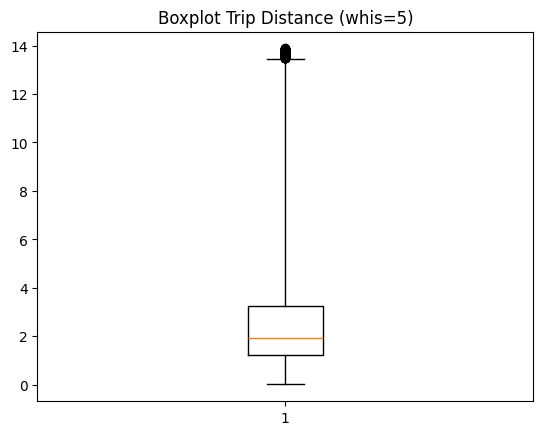

In [43]:
#melihat boxplot dari trip_distance data yang telah difilter
plt.figure()

plt.boxplot(
    df_filtered['trip_distance'],
    whis=5  # ini artinya 5 * IQR
)

plt.title('Boxplot Trip Distance (whis=5)')
plt.show()


1.5.2 Melihat outlier pada amount data clean

In [44]:
# Melihat outlier dari Total_amount
q1_amount = df_filtered['total_amount'].quantile(0.25)
q2_amount = df_filtered['total_amount'].quantile(0.50)
q3_amount = df_filtered['total_amount'].quantile(0.75)

IQR = q3_amount-q1_amount
upper_bound_amount = q3_amount + 5*IQR
lower_bound_amount = q1_amount - 5*IQR
print(upper_bound_amount)
print(lower_bound_amount)

df_filtered.loc[df_filtered['total_amount']>=upper_bound_amount, : ].count() #populasi sangat sedikit, dihapus saja

89.60999999999999
-50.91499999999999


VendorID                 53
lpep_pickup_datetime     53
lpep_dropoff_datetime    53
store_and_fwd_flag       53
RatecodeID               53
PULocationID             53
PU_Zone                  53
PU_borough               53
PU_service_zone          53
DOLocationID             53
passenger_count          53
trip_distance            53
fare_amount              53
extra                    53
mta_tax                  53
tip_amount               53
tolls_amount             53
improvement_surcharge    53
total_amount             53
payment_type             53
trip_type                53
congestion_surcharge     53
RateCode_desc            53
payment_type_desc        53
trip_type_desc           53
DO_borough               53
DO_Zone                  53
DO_service_zone          53
dtype: int64

1.5.3 menghapus outlier total amount (53 data)

In [45]:
df_filtered = df_filtered[df_filtered['total_amount'] <= upper_bound_amount]
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63526 entries, 0 to 67426
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               63526 non-null  int64         
 1   lpep_pickup_datetime   63526 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  63526 non-null  datetime64[ns]
 3   store_and_fwd_flag     63526 non-null  object        
 4   RatecodeID             63526 non-null  float64       
 5   PULocationID           63526 non-null  int64         
 6   PU_Zone                63526 non-null  object        
 7   PU_borough             63526 non-null  object        
 8   PU_service_zone        63526 non-null  object        
 9   DOLocationID           63526 non-null  int64         
 10  passenger_count        63526 non-null  int64         
 11  trip_distance          63526 non-null  float64       
 12  fare_amount            63526 non-null  float64       
 13  extra 

1.5.3 menghapus outlier waktu (tertinggal karena baru dipahami bahwa dataset dimaksud adalah transaksi Januari 2023)

In [46]:
df_filtered = df_filtered[df_filtered['lpep_pickup_datetime'].dt.year != 2022]
df_filtered.sort_values(by='lpep_pickup_datetime', ascending = True)

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,PU_Zone,PU_borough,PU_service_zone,DOLocationID,...,total_amount,payment_type,trip_type,congestion_surcharge,RateCode_desc,payment_type_desc,trip_type_desc,DO_borough,DO_Zone,DO_service_zone
24,2,2023-01-01 00:01:31,2023-01-01 00:16:02,N,1.0,166,Morningside Heights,Manhattan,Boro Zone,244,...,22.56,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Manhattan,Washington Heights South,Boro Zone
44,2,2023-01-01 00:04:25,2023-01-01 00:17:50,N,1.0,255,Williamsburg (North Side),Brooklyn,Boro Zone,146,...,21.60,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Queens,Long Island City/Queens Plaza,Boro Zone
57,2,2023-01-01 00:06:48,2023-01-01 01:08:47,N,1.0,129,Jackson Heights,Queens,Boro Zone,226,...,54.50,2.0,1.0,0.00,Standard rate,Cash,Street-hail,Queens,Sunnyside,Boro Zone
41,2,2023-01-01 00:08:05,2023-01-01 00:13:26,N,1.0,41,Central Harlem,Manhattan,Boro Zone,75,...,8.16,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Manhattan,East Harlem South,Boro Zone
11,2,2023-01-01 00:08:43,2023-01-01 00:17:08,N,1.0,75,East Harlem South,Manhattan,Boro Zone,140,...,19.98,1.0,1.0,2.75,Standard rate,Credit card,Street-hail,Manhattan,Lenox Hill East,Yellow Zone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67426,2,2023-01-31 23:51:00,2023-02-01 00:07:00,N,1.0,256,Williamsburg (South Side),Brooklyn,Boro Zone,140,...,29.40,1.0,1.0,0.00,Unknown,Credit card,Street-hail,Manhattan,Lenox Hill East,Yellow Zone
63097,2,2023-01-31 23:53:41,2023-02-01 00:31:14,N,1.0,82,Elmhurst,Queens,Boro Zone,83,...,40.50,2.0,1.0,0.00,Standard rate,Cash,Street-hail,Queens,Elmhurst/Maspeth,Boro Zone
63081,2,2023-01-31 23:56:16,2023-02-01 00:03:16,N,1.0,95,Forest Hills,Queens,Boro Zone,196,...,13.32,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Queens,Rego Park,Boro Zone
63093,2,2023-01-31 23:58:23,2023-02-01 00:07:16,N,1.0,95,Forest Hills,Queens,Boro Zone,135,...,15.84,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Queens,Kew Gardens Hills,Boro Zone


# BAB 2 EKSPLORASI DATA

## 2.1 Revenue Breakdown by Location and Route

In [47]:
total_revenue = df_filtered['total_amount'].sum()
total_perjalanan = df_filtered['lpep_pickup_datetime'].count()
print(f"total revenue periode Desember 22 s.d. Januari 23 : $ {total_revenue :,.0f}")
print(f"total demand Desember 22 s.d. Januari 23 : {total_perjalanan :,.0f} perjalanan")

total revenue periode Desember 22 s.d. Januari 23 : $ 1,330,892
total demand Desember 22 s.d. Januari 23 : 63,524 perjalanan


2.1.1 Revenue Pivotting

In [48]:
# Total Revenue Berdasarkan PU borough
revenue_pu = df_filtered.groupby('PU_borough')['total_amount'].sum().reset_index()

revenue_pu = revenue_pu.sort_values(by='total_amount', ascending=False)

revenue_pu

,PU_borough,total_amount
2,Manhattan,764374.32
3,Queens,338845.92
1,Brooklyn,207429.59
0,Bronx,19053.29
5,Unknown,960.38
4,Staten Island,228.41


2.1.2 Revenue Pivotting breakdown

In [49]:
# rute yang paling ramai (dari semuanya)
route_summary = df_filtered.groupby(
    ['PU_Zone', 'DO_Zone', 'PU_borough', 'DO_borough']
).agg(
    count=('total_amount', 'size'),
    total_revenue=('total_amount', 'sum')
).reset_index()

route_summary = route_summary.sort_values(by='count', ascending=False)

route_summary.head()

,PU_Zone,DO_Zone,PU_borough,DO_borough,count,total_revenue
1573,East Harlem North,East Harlem South,Manhattan,Manhattan,1974,26214.14
1703,East Harlem South,East Harlem North,Manhattan,Manhattan,1431,17677.02
1653,East Harlem North,Upper East Side North,Manhattan,Manhattan,1175,23586.14
2247,Forest Hills,Forest Hills,Queens,Queens,1133,14478.40
1557,East Harlem North,Central Harlem,Manhattan,Manhattan,953,11096.44


2.1.3 Heatmap Preparation per Borough

In [50]:
pivot_borough = df_filtered.pivot_table(
    index='PU_borough',
    columns='DO_borough',
    aggfunc='size',
    fill_value=0
)

pivot_borough

DO_borough,Bronx,Brooklyn,Manhattan,Queens,Staten Island,Unknown
PU_borough,,,,,,
Bronx,582,1,241,16,0,12
Brooklyn,8,6311,1542,383,0,25
Manhattan,1430,127,35774,707,0,63
Queens,34,413,868,14846,0,93
Staten Island,0,1,0,0,8,0
Unknown,1,1,0,7,0,30


2.1.4 Pembentukan Heatmap 

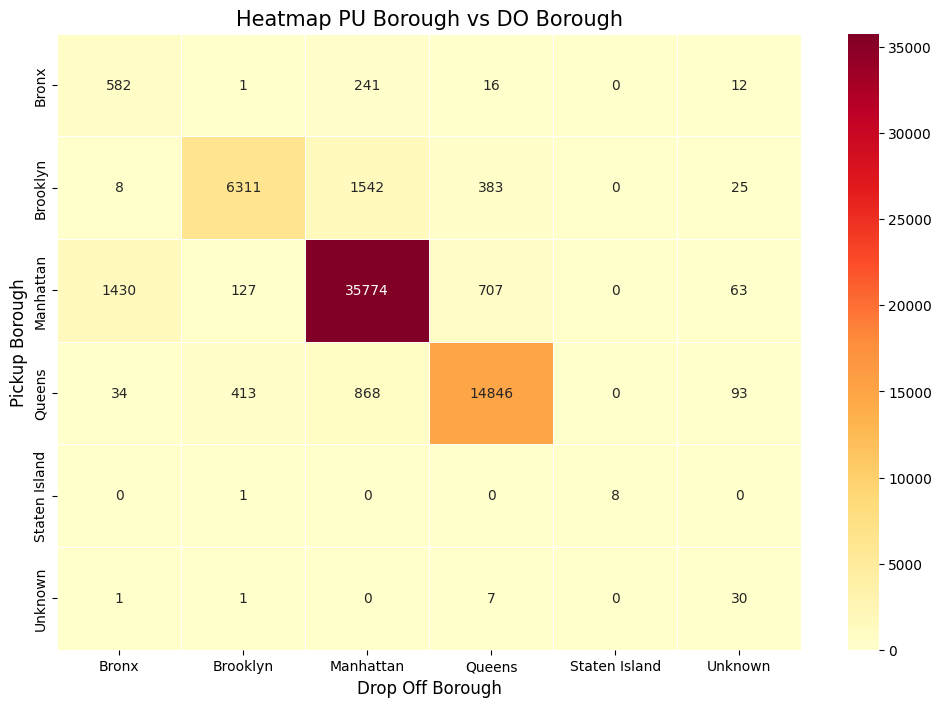

In [51]:
#Perjalanan paling banyak adalah didalam Manhattan (Manhattan ke Manhattan)
import seaborn as sns

plt.figure(figsize=(12, 8)) # Ukuran disesuaikan agar teks tidak bertumpuk

sns.heatmap(
    pivot_borough,
    cmap='YlOrRd',      # Gradasi Kuning ke Merah
    annot=True, 
    fmt='g',
    linewidths=.5       # Memberikan garis tipis antar kotak agar lebih bersih
)

plt.title('Heatmap PU Borough vs DO Borough', fontsize=15)
plt.xlabel('Drop Off Borough', fontsize=12)
plt.ylabel('Pickup Borough', fontsize=12)

plt.show()

2.1.5 Menyelami perjalanan di Manhattan

In [52]:
# Deepdive didalam Manhattan untuk melihat demand terbesar (Manhattan-Manhattan) perjalanan PU Zone vs DO Zone
df_filtered_manhattan = df_filtered.loc[(df['PU_borough']=='Manhattan') & (df['DO_borough']=='Manhattan'), :]
df_filtered_manhattan.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,PU_Zone,PU_borough,PU_service_zone,DOLocationID,...,total_amount,payment_type,trip_type,congestion_surcharge,RateCode_desc,payment_type_desc,trip_type_desc,DO_borough,DO_Zone,DO_service_zone
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,Morningside Heights,Manhattan,Boro Zone,143,...,24.18,1.0,1.0,2.75,Standard rate,Credit card,Street-hail,Manhattan,Lincoln Square West,Yellow Zone
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,Bloomingdale,Manhattan,Yellow Zone,43,...,15.84,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Manhattan,Central Park,Yellow Zone
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,Central Harlem,Manhattan,Boro Zone,238,...,10.20,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Manhattan,Upper West Side North,Yellow Zone
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,Central Harlem,Manhattan,Boro Zone,74,...,8.00,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,Manhattan,East Harlem North,Boro Zone
5,2,2023-01-01 00:53:31,2023-01-01 01:11:04,N,1.0,41,Central Harlem,Manhattan,Boro Zone,262,...,22.95,2.0,1.0,2.75,Standard rate,Cash,Street-hail,Manhattan,Yorkville East,Yellow Zone


2.1.6 melihat perbandingan PU dan DO Zone di Manhattan

In [53]:
#Kita lihat PU_Zone nya ada berapa
print(f"jumlah pu zone: {len(df_filtered_manhattan['PU_Zone'].value_counts())}")
print(f"jumlah do zone: {len(df_filtered_manhattan['DO_Zone'].value_counts())}")

jumlah pu zone: 22
jumlah do zone: 66


2.1.7 melihat zona yang berpengaruh di Manhattan (Zona Padat)

In [54]:
# Pareto PU Zone di Manhattan
pu_count_manhattan = df_filtered_manhattan.groupby('PU_Zone').size().reset_index(name='count')

pu_count_manhattan = pu_count_manhattan.sort_values(by='count', ascending=False)

pu_count_manhattan['percentage'] = pu_count_manhattan['count'] / pu_count_manhattan['count'].sum() * 100
pu_count_manhattan['cum_percentage'] = pu_count_manhattan['percentage'].cumsum()

pu_pareto_manhattan = pu_count_manhattan[pu_count_manhattan['cum_percentage'] <= 80]

pu_pareto_manhattan

,PU_Zone,count,percentage,cum_percentage
4,East Harlem North,12183,34.055459,34.055459
5,East Harlem South,8309,23.226366,57.281825
15,Morningside Heights,3666,10.247666,67.529491
1,Central Harlem,3623,10.127467,77.656958


In [55]:
#Pareto DO Zone di Manhattan
do_count_manhattan = df_filtered_manhattan.groupby('DO_Zone').size().reset_index(name='count')

do_count_manhattan = do_count_manhattan.sort_values(by='count', ascending=False)

do_count_manhattan['percentage'] = do_count_manhattan['count'] / do_count_manhattan['count'].sum() * 100
do_count_manhattan['cum_percentage'] = do_count_manhattan['percentage'].cumsum()

do_pareto_manhattan = do_count_manhattan[do_count_manhattan['cum_percentage'] <= 80]

do_pareto_manhattan

,DO_Zone,count,percentage,cum_percentage
12,East Harlem South,3325,9.294460,9.294460
11,East Harlem North,3219,8.998155,18.292615
55,Upper East Side North,2673,7.471907,25.764522
4,Central Harlem,2499,6.985520,32.750042
57,Upper West Side North,2276,6.362162,39.112204
5,Central Harlem North,2208,6.172080,45.284285
41,Morningside Heights,2198,6.144127,51.428412
65,Yorkville West,1489,4.162241,55.590652
58,Upper West Side South,1441,4.028065,59.618718
33,Manhattan Valley,1424,3.980545,63.599262


2.1.8 Heatmap berdasarkan zona padat di manhattan

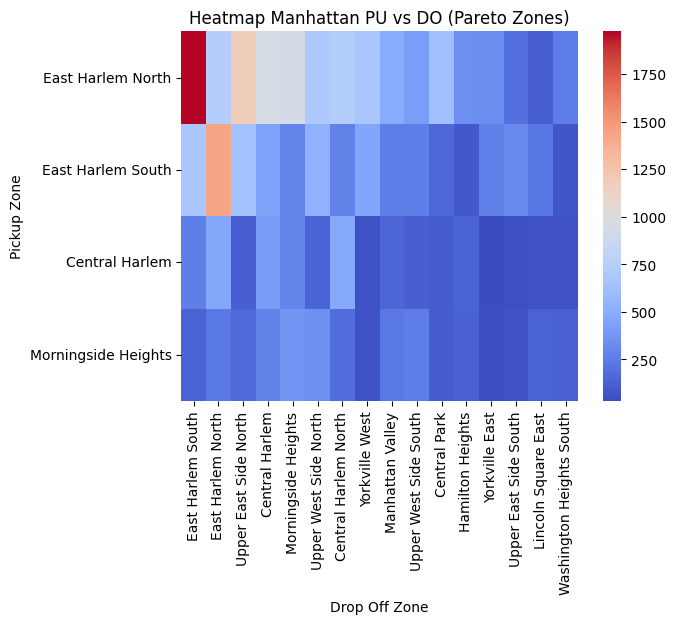

In [56]:
# Heatmap nya

pu_pareto_zones_manhattan = pu_pareto_manhattan['PU_Zone']
do_pareto_zones_manhattan = do_pareto_manhattan['DO_Zone']
df_manhattan_pareto = df_filtered_manhattan[
    (df_filtered_manhattan['PU_Zone'].isin(pu_pareto_zones_manhattan)) &
    (df_filtered_manhattan['DO_Zone'].isin(do_pareto_zones_manhattan))
]
pivot_manhattan = df_manhattan_pareto.pivot_table(
    index='PU_Zone',
    columns='DO_Zone',
    aggfunc='size',
    fill_value=0
)

pivot_manhattan = pivot_manhattan.loc[
    pivot_manhattan.sum(axis=1).sort_values(ascending=False).index,
    pivot_manhattan.sum(axis=0).sort_values(ascending=False).index
]

plt.figure()

sns.heatmap(
    pivot_manhattan,
    cmap='coolwarm'
)

plt.title('Heatmap Manhattan PU vs DO (Pareto Zones)')
plt.xlabel('Drop Off Zone')
plt.ylabel('Pickup Zone')

plt.show()

2.1.9 Breakdown berdasarkan perjalanan paling banyak PU_Zone nya, kemudian dibuat menjadi horizontal barplot dan warnanya dibedakan

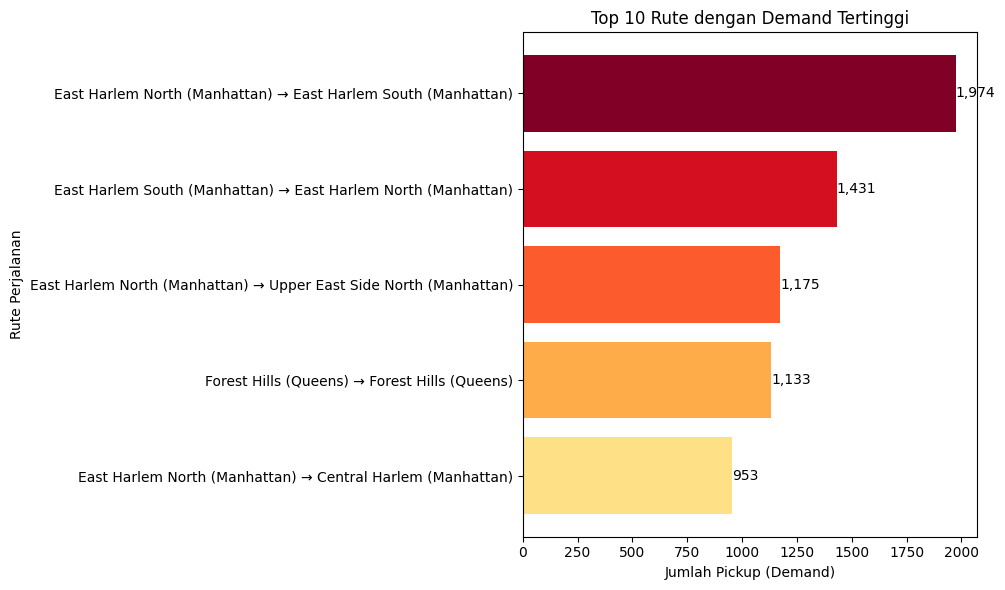

In [57]:

df_filtered['trip_detail'] = (
    df_filtered['PU_Zone'].astype(str) + ' (' + df_filtered['PU_borough'].astype(str) + ')' +
    ' → ' +
    df_filtered['DO_Zone'].astype(str) + ' (' + df_filtered['DO_borough'].astype(str) + ')'
) # buat kolom baru

trip_demand = (
    df_filtered
    .groupby('trip_detail')
    .size()
    .reset_index(name='demand')
) # group by berdasarkan trip_detail

top10_trip = (
    trip_demand
    .sort_values(by='demand', ascending=False)
    .head(5)
    .sort_values(by='demand')  # biar enak dibaca di barh
)


plt.figure(figsize=(10,6))

# Generate warna berbeda
colors = plt.cm.YlOrRd(np.linspace(0.2, 1, len(top10_trip)))

bars = plt.barh(
    top10_trip['trip_detail'],
    top10_trip['demand'],
    color=colors
)

plt.xlabel('Jumlah Pickup (Demand)')
plt.ylabel('Rute Perjalanan')
plt.title('Top 10 Rute dengan Demand Tertinggi')

# Label angka di bar
for i, v in enumerate(top10_trip['demand']):
    plt.text(v, i, f"{v:,}", va='center')

plt.tight_layout()
plt.show()

2.1.10 Breakdown Zona Sepi

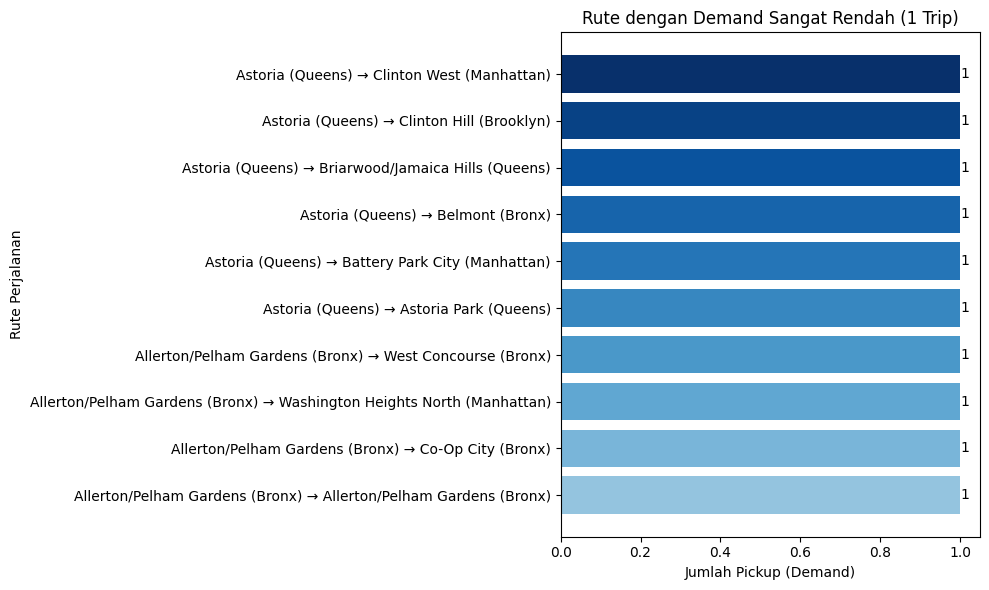

In [58]:
# Filter trip dengan demand = 1
rare_trip = trip_demand[trip_demand['demand'] == 1]

# Optional: kalau terlalu banyak, ambil sebagian (misal 10)
rare_trip = rare_trip.head(10)

plt.figure(figsize=(10,6))

# Gradasi biru
colors = plt.cm.Blues(np.linspace(0.4, 1, len(rare_trip)))

bars = plt.barh(
    rare_trip['trip_detail'],
    rare_trip['demand'],
    color=colors
)

plt.xlabel('Jumlah Pickup (Demand)')
plt.ylabel('Rute Perjalanan')
plt.title('Rute dengan Demand Sangat Rendah (1 Trip)')

# Label angka
for i, v in enumerate(rare_trip['demand']):
    plt.text(v, i, f"{v:,}", va='center')

plt.tight_layout()
plt.show()

## 2.2 Breakdown berdasarkan waktu

2.2.1 Breakdown kolom df_filtered

In [59]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63524 entries, 0 to 67426
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               63524 non-null  int64         
 1   lpep_pickup_datetime   63524 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  63524 non-null  datetime64[ns]
 3   store_and_fwd_flag     63524 non-null  object        
 4   RatecodeID             63524 non-null  float64       
 5   PULocationID           63524 non-null  int64         
 6   PU_Zone                63524 non-null  object        
 7   PU_borough             63524 non-null  object        
 8   PU_service_zone        63524 non-null  object        
 9   DOLocationID           63524 non-null  int64         
 10  passenger_count        63524 non-null  int64         
 11  trip_distance          63524 non-null  float64       
 12  fare_amount            63524 non-null  float64       
 13  extra 

In [60]:
df_filtered['pickup_hour'] = df_filtered['lpep_pickup_datetime'].dt.hour
df_filtered['dropoff_hour'] = df_filtered['lpep_dropoff_datetime'].dt.hour

In [61]:
df_filtered.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,PU_Zone,PU_borough,PU_service_zone,DOLocationID,...,congestion_surcharge,RateCode_desc,payment_type_desc,trip_type_desc,DO_borough,DO_Zone,DO_service_zone,trip_detail,pickup_hour,dropoff_hour
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,Morningside Heights,Manhattan,Boro Zone,143,...,2.75,Standard rate,Credit card,Street-hail,Manhattan,Lincoln Square West,Yellow Zone,Morningside Heights (Manhattan) → Lincoln Squa...,0,0
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,Bloomingdale,Manhattan,Yellow Zone,43,...,0.00,Standard rate,Credit card,Street-hail,Manhattan,Central Park,Yellow Zone,Bloomingdale (Manhattan) → Central Park (Manha...,0,0
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,Central Harlem,Manhattan,Boro Zone,238,...,0.00,Standard rate,Credit card,Street-hail,Manhattan,Upper West Side North,Yellow Zone,Central Harlem (Manhattan) → Upper West Side N...,0,0
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,Central Harlem,Manhattan,Boro Zone,74,...,0.00,Standard rate,Credit card,Street-hail,Manhattan,East Harlem North,Boro Zone,Central Harlem (Manhattan) → East Harlem North...,0,0
5,2,2023-01-01 00:53:31,2023-01-01 01:11:04,N,1.0,41,Central Harlem,Manhattan,Boro Zone,262,...,2.75,Standard rate,Cash,Street-hail,Manhattan,Yorkville East,Yellow Zone,Central Harlem (Manhattan) → Yorkville East (M...,0,1


2.2.2 Melihat distribusi total amount untuk dibandingkan dengan jam nya nanti, sebagai alat untuk melihat per jam nya diisi menggunakan mean atau median

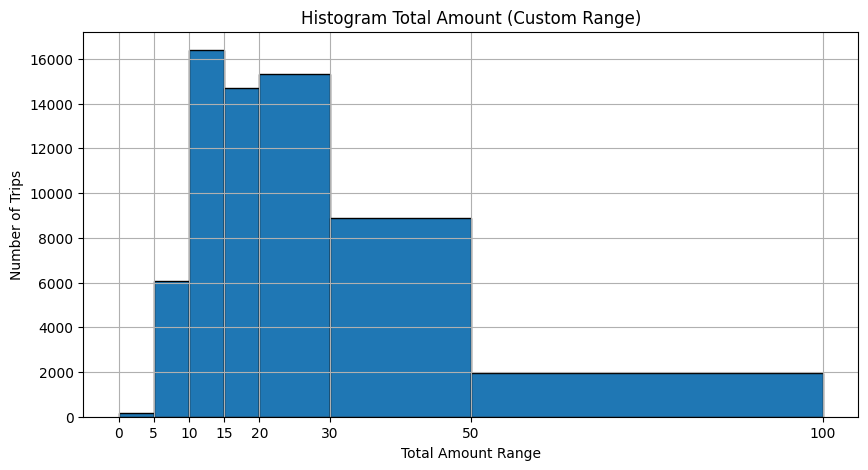

In [62]:
bins = [0, 5, 10, 15, 20, 30, 50, 100]

plt.figure(figsize=(10,5))
plt.hist(
    df_filtered['total_amount'],
    bins=bins,
    edgecolor='black'
)

plt.title('Histogram Total Amount (Custom Range)')
plt.xlabel('Total Amount Range')
plt.ylabel('Number of Trips')

plt.xticks(bins)
plt.grid()
plt.show()

2.2.3 Melihat rata-rata amount per trip di setiap jam

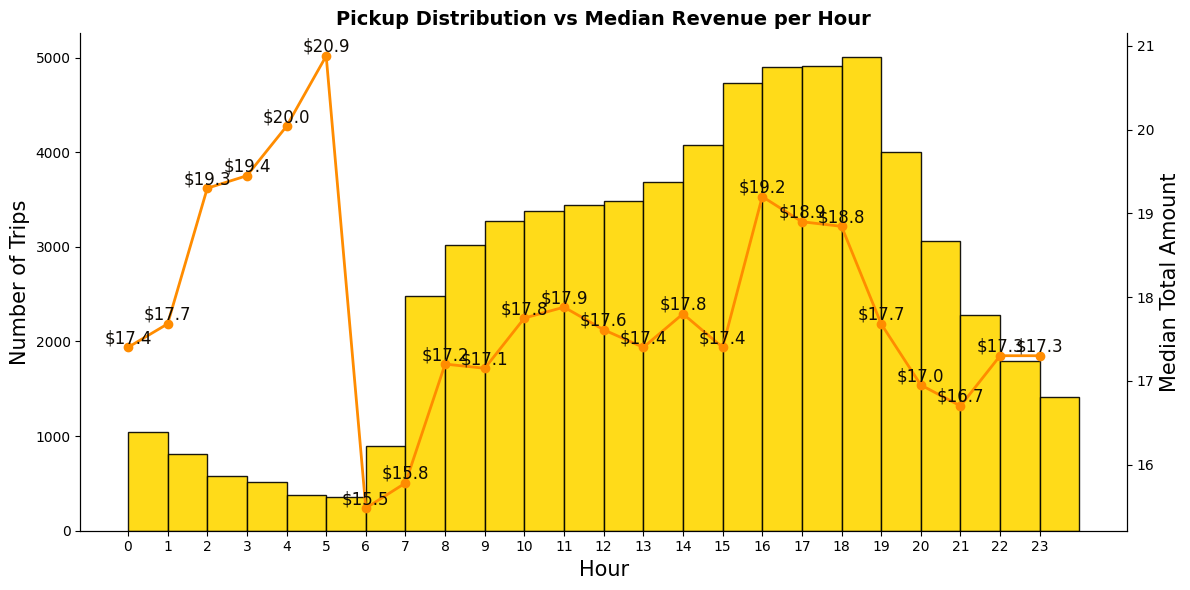

In [63]:
# Median per jam
avg_per_hour = df_filtered.groupby('pickup_hour')['total_amount'].median().reset_index()
avg_per_hour = avg_per_hour.sort_values('pickup_hour')

fig, ax1 = plt.subplots(figsize=(12,6))

# ======================
# Histogram (axis kiri)
# ======================
ax1.hist(
    df_filtered['pickup_hour'],
    bins=range(25),
    color='#FFD700',       # 👉 kuning lebih solid (gold)
    edgecolor='black',
    alpha=0.9
)

ax1.set_xlabel('Hour', fontsize=15)
ax1.set_ylabel('Number of Trips', fontsize=15)
ax1.set_xticks(range(24))

# Hilangkan grid
ax1.grid(False)

# ======================
# Line Plot (axis kanan)
# ======================
ax2 = ax1.twinx()

ax2.plot(
    avg_per_hour['pickup_hour'],
    avg_per_hour['total_amount'],
    marker='o',
    color='#FF8C00',   # 👉 orange lebih elegan
    linewidth=2
)

ax2.set_ylabel('Median Total Amount', fontsize=15)

# Label tiap titik (lebih clean)
for x, y in zip(avg_per_hour['pickup_hour'], avg_per_hour['total_amount']):
    ax2.text(
        x, y,
        f"${y:.1f}",
        ha='center',
        va='bottom',
        fontsize=12,
        color="#0F0B06"
    )

# ======================
# Styling tambahan
# ======================
plt.title('Pickup Distribution vs Median Revenue per Hour', fontsize=14, weight='bold')

# Hilangkan garis atas kanan biar minimalis
for spine in ['top']:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

2.2.4 Mengelompokkan demand

In [64]:
# Data tidak terdistribusi normal, menggunakan sehingga segmentasi menggunakan median dan quartil
hour_count = df_filtered.groupby('pickup_hour').size().reset_index(name='num_trips')
Q1 = hour_count['num_trips'].quantile(0.25)
Q2 = hour_count['num_trips'].quantile(0.50)
Q3 = hour_count['num_trips'].quantile(0.75)

print(Q1, Q2, Q3)

1006.0 3039.5 3765.75


In [65]:
# Melakukan segmentasi dan diapply ke df_filtered
def segment_demand(x):
    if x < Q1:
        return "Very Low Demand (01-06)"
    elif Q1 <= x < Q2:
        return "Low Demand (21-00 dan 07)"
    elif Q2 <= x < Q3:
        return "Moderate (09-13 dan 20)"
    else:
        return "Peak Hour (14-19)"

hour_count['demand_flag'] = hour_count['num_trips'].apply(segment_demand)

In [66]:
hour_count.sort_values(by='pickup_hour')

,pickup_hour,num_trips,demand_flag
0,0,1044,Low Demand (21-00 dan 07)
1,1,816,Very Low Demand (01-06)
2,2,582,Very Low Demand (01-06)
3,3,515,Very Low Demand (01-06)
4,4,382,Very Low Demand (01-06)
5,5,355,Very Low Demand (01-06)
6,6,892,Very Low Demand (01-06)
7,7,2477,Low Demand (21-00 dan 07)
8,8,3021,Low Demand (21-00 dan 07)
9,9,3277,Moderate (09-13 dan 20)


2.2.5 Membuat kolom demand_flag untuk diolah

In [67]:
#diapply ke tabel df_filtered
hour_flag_map = dict(zip(hour_count['pickup_hour'], hour_count['demand_flag']))
df_filtered['demand_flag'] = df_filtered['pickup_hour'].map(hour_flag_map)


In [68]:
# Demand Keseluruhan
df_filtered['demand_flag'].value_counts()

demand_flag
Peak Hour (14-19)            27631
Moderate (09-13 dan 20)      20323
Low Demand (21-00 dan 07)    12028
Very Low Demand (01-06)       3542
Name: count, dtype: int64

2.2.6 Melihat distribusi demand_flag di setiap borough

In [69]:
breakdown = df_filtered.groupby('PU_borough')['demand_flag'].value_counts().unstack(fill_value=0)
breakdown_pct = breakdown.div(breakdown.sum(axis=1), axis=0) * 100
display(breakdown)
display(breakdown_pct.round(2))

demand_flag,Low Demand (21-00 dan 07),Moderate (09-13 dan 20),Peak Hour (14-19),Very Low Demand (01-06)
PU_borough,,,,
Bronx,147,344,290,71
Brooklyn,1633,2375,3501,760
Manhattan,7056,13432,16340,1273
Queens,3187,4164,7478,1425
Staten Island,1,1,6,1
Unknown,4,7,16,12


demand_flag,Low Demand (21-00 dan 07),Moderate (09-13 dan 20),Peak Hour (14-19),Very Low Demand (01-06)
PU_borough,,,,
Bronx,17.25,40.38,34.04,8.33
Brooklyn,19.75,28.72,42.34,9.19
Manhattan,18.52,35.25,42.89,3.34
Queens,19.61,25.62,46.01,8.77
Staten Island,11.11,11.11,66.67,11.11
Unknown,10.26,17.95,41.03,30.77


## 2.3. Membandingkan variabel kategorik tipe pembayaran dengan revenue

In [70]:
#Melihat kembali dataframe
display(df_filtered.head())
df_filtered.info()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,PU_Zone,PU_borough,PU_service_zone,DOLocationID,...,RateCode_desc,payment_type_desc,trip_type_desc,DO_borough,DO_Zone,DO_service_zone,trip_detail,pickup_hour,dropoff_hour,demand_flag
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,Morningside Heights,Manhattan,Boro Zone,143,...,Standard rate,Credit card,Street-hail,Manhattan,Lincoln Square West,Yellow Zone,Morningside Heights (Manhattan) → Lincoln Squa...,0,0,Low Demand (21-00 dan 07)
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,Bloomingdale,Manhattan,Yellow Zone,43,...,Standard rate,Credit card,Street-hail,Manhattan,Central Park,Yellow Zone,Bloomingdale (Manhattan) → Central Park (Manha...,0,0,Low Demand (21-00 dan 07)
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,Central Harlem,Manhattan,Boro Zone,238,...,Standard rate,Credit card,Street-hail,Manhattan,Upper West Side North,Yellow Zone,Central Harlem (Manhattan) → Upper West Side N...,0,0,Low Demand (21-00 dan 07)
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,Central Harlem,Manhattan,Boro Zone,74,...,Standard rate,Credit card,Street-hail,Manhattan,East Harlem North,Boro Zone,Central Harlem (Manhattan) → East Harlem North...,0,0,Low Demand (21-00 dan 07)
5,2,2023-01-01 00:53:31,2023-01-01 01:11:04,N,1.0,41,Central Harlem,Manhattan,Boro Zone,262,...,Standard rate,Cash,Street-hail,Manhattan,Yorkville East,Yellow Zone,Central Harlem (Manhattan) → Yorkville East (M...,0,1,Low Demand (21-00 dan 07)


<class 'pandas.core.frame.DataFrame'>
Index: 63524 entries, 0 to 67426
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               63524 non-null  int64         
 1   lpep_pickup_datetime   63524 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  63524 non-null  datetime64[ns]
 3   store_and_fwd_flag     63524 non-null  object        
 4   RatecodeID             63524 non-null  float64       
 5   PULocationID           63524 non-null  int64         
 6   PU_Zone                63524 non-null  object        
 7   PU_borough             63524 non-null  object        
 8   PU_service_zone        63524 non-null  object        
 9   DOLocationID           63524 non-null  int64         
 10  passenger_count        63524 non-null  int64         
 11  trip_distance          63524 non-null  float64       
 12  fare_amount            63524 non-null  float64       
 13  extra 

In [71]:
df_filtered['payment_type_desc'].value_counts()


payment_type_desc
Credit card    41849
Cash           21512
No charge        136
Dispute           27
Name: count, dtype: int64

2.3.1 Melihat normalitas dari total_amount lagi

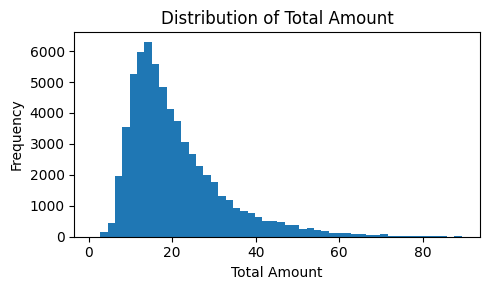

In [72]:
#Melihat normalitas data revenue
data = df_filtered['total_amount'].dropna()

plt.figure(figsize=(5,3))
plt.hist(data, bins=50)

plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

2.3.1 Uji statistik antara payment_type_desc dengan total amount untuk melihat apakah revenue dari kartu kredit berbeda signifikan dengan cash

In [73]:
#Data amount tidak normal diuji menggunakan Kruskall-Walis Test
from scipy import stats
df_kw = df_filtered[['payment_type_desc', 'total_amount']].dropna()
groups = [
    group['total_amount'].values
    for name, group in df_kw.groupby('payment_type_desc')
]
kw_stat, p_value = stats.kruskal(*groups)

print("Kruskal-Wallis Statistic:", kw_stat)
print(f"p-value: {p_value:.2e}")

Kruskal-Wallis Statistic: 4625.8699016803785
p-value: 0.00e+00


2.3.2 Membandingkan revenue berdasarkan tipe pembayaran

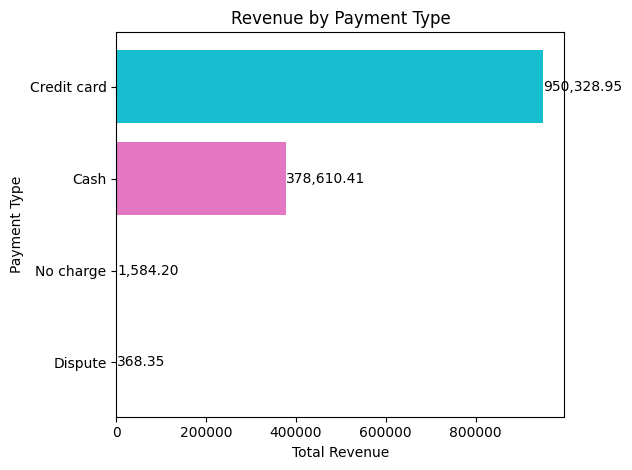

In [74]:
revenue_by_payment = (
    df_filtered
    .groupby('payment_type_desc')['total_amount']
    .sum()
    .sort_values()
)
colors = plt.cm.tab10(np.linspace(0, 1, len(revenue_by_payment)))

bars = plt.barh(
    revenue_by_payment.index,
    revenue_by_payment.values,
    color=colors
)


# Tambahkan label di tiap bar
for i, v in enumerate(revenue_by_payment.values):
    plt.text(v, i, f"{v:,.2f}", va='center')

plt.xlabel("Total Revenue")
plt.ylabel("Payment Type")
plt.title("Revenue by Payment Type")

plt.tight_layout()
plt.show()

Insight
1. Terdapat perbedaan revenue antara Credit Card dan Cash (rata-rata payment sudah cashless)
2. Kategori pembayaran berpengaruh terhadap total_revenue

In [75]:
df_filtered.head()
df_filtered_nonmanhattan = df_filtered.loc[df['PU_borough']!='Manhattan', : ]
df_filtered_nonmanhattan.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,PU_Zone,PU_borough,PU_service_zone,DOLocationID,...,RateCode_desc,payment_type_desc,trip_type_desc,DO_borough,DO_Zone,DO_service_zone,trip_detail,pickup_hour,dropoff_hour,demand_flag
6,1,2023-01-01 00:09:14,2023-01-01 00:26:39,N,1.0,181,Park Slope,Brooklyn,Boro Zone,45,...,Standard rate,Credit card,Street-hail,Manhattan,Chinatown,Yellow Zone,Park Slope (Brooklyn) → Chinatown (Manhattan),0,0,Low Demand (21-00 dan 07)
10,1,2023-01-01 00:16:12,2023-01-01 00:41:43,N,1.0,255,Williamsburg (North Side),Brooklyn,Boro Zone,234,...,Standard rate,Credit card,Street-hail,Manhattan,Union Sq,Yellow Zone,Williamsburg (North Side) (Brooklyn) → Union S...,0,0,Low Demand (21-00 dan 07)
13,2,2023-01-01 00:18:35,2023-01-01 00:30:09,N,1.0,66,DUMBO/Vinegar Hill,Brooklyn,Boro Zone,255,...,Standard rate,Credit card,Street-hail,Brooklyn,Williamsburg (North Side),Boro Zone,DUMBO/Vinegar Hill (Brooklyn) → Williamsburg (...,0,0,Low Demand (21-00 dan 07)
14,2,2023-01-01 00:39:32,2023-01-01 01:18:06,N,1.0,255,Williamsburg (North Side),Brooklyn,Boro Zone,186,...,Standard rate,Cash,Street-hail,Manhattan,Penn Station/Madison Sq West,Yellow Zone,Williamsburg (North Side) (Brooklyn) → Penn St...,0,1,Low Demand (21-00 dan 07)
15,1,2023-01-01 00:49:34,2023-01-01 01:08:23,N,1.0,195,Red Hook,Brooklyn,Boro Zone,210,...,Standard rate,Cash,Street-hail,Brooklyn,Sheepshead Bay,Boro Zone,Red Hook (Brooklyn) → Sheepshead Bay (Brooklyn),0,1,Low Demand (21-00 dan 07)


# 2.4. Tipe Trip terhadap revenue dan demand

In [76]:
df_filtered['trip_type_desc'].value_counts()

trip_type_desc
Street-hail    62764
Dispatch         760
Name: count, dtype: int64

1. Penggunaan taxi masih sangat tradisional dengan menghentikan secara langsung, perlu adanya inovasi bisnis
2. Untuk setidaknya mengambil sedikit market share dari online

## 2.5 Breakdown berdasarkan jarak

2.5.1. Melihat distribusi jarak

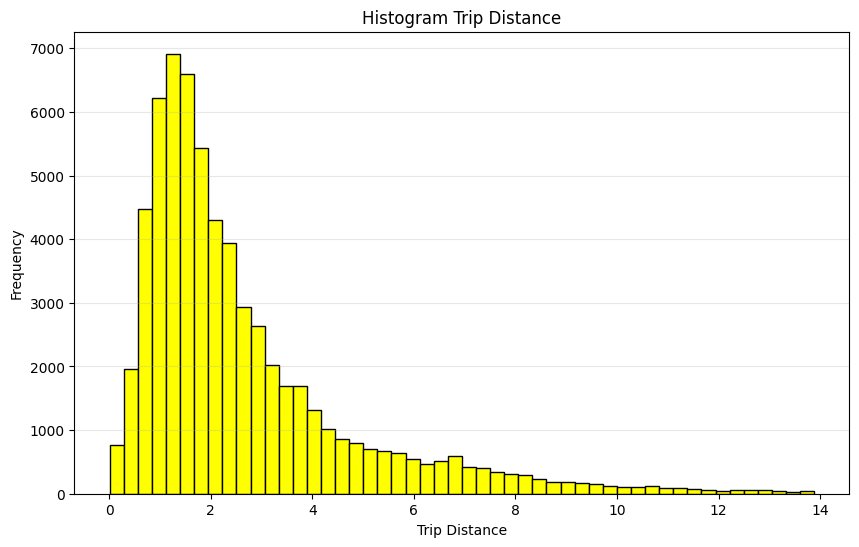

In [77]:
# histogram jarak
plt.figure(figsize=(10, 6))
plt.hist(df_filtered['trip_distance'], bins=50, color='yellow', edgecolor='black') # Menambahkan warna kuning dan garis tepi hitam agar lebih rapi
plt.title('Histogram Trip Distance')
plt.xlabel('Trip Distance')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3) # Opsional: menambahkan grid halus di sumbu y
plt.show()

In [78]:
#mengikuti data segmentasi global
very_low_distance_bound = 1
low_distance_bound = 3
medium_distance_bound = 8
high_distance_bound = 20
def distance_flag(x):
    if x < very_low_distance_bound:
        return "very low distance"
    elif very_low_distance_bound <= x < low_distance_bound:
        return "low distance"
    elif low_distance_bound <= x < medium_distance_bound:
        return "moderate distance"
    elif medium_distance_bound <= x < high_distance_bound:
        return "high distance"
    else:
        return "very high distance"

df_filtered['flag_distance'] = df_filtered['trip_distance'].apply(distance_flag)
df_filtered.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,PU_Zone,PU_borough,PU_service_zone,DOLocationID,...,payment_type_desc,trip_type_desc,DO_borough,DO_Zone,DO_service_zone,trip_detail,pickup_hour,dropoff_hour,demand_flag,flag_distance
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,Morningside Heights,Manhattan,Boro Zone,143,...,Credit card,Street-hail,Manhattan,Lincoln Square West,Yellow Zone,Morningside Heights (Manhattan) → Lincoln Squa...,0,0,Low Demand (21-00 dan 07),low distance
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,Bloomingdale,Manhattan,Yellow Zone,43,...,Credit card,Street-hail,Manhattan,Central Park,Yellow Zone,Bloomingdale (Manhattan) → Central Park (Manha...,0,0,Low Demand (21-00 dan 07),low distance
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,Central Harlem,Manhattan,Boro Zone,238,...,Credit card,Street-hail,Manhattan,Upper West Side North,Yellow Zone,Central Harlem (Manhattan) → Upper West Side N...,0,0,Low Demand (21-00 dan 07),low distance
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,Central Harlem,Manhattan,Boro Zone,74,...,Credit card,Street-hail,Manhattan,East Harlem North,Boro Zone,Central Harlem (Manhattan) → East Harlem North...,0,0,Low Demand (21-00 dan 07),low distance
5,2,2023-01-01 00:53:31,2023-01-01 01:11:04,N,1.0,41,Central Harlem,Manhattan,Boro Zone,262,...,Cash,Street-hail,Manhattan,Yorkville East,Yellow Zone,Central Harlem (Manhattan) → Yorkville East (M...,0,1,Low Demand (21-00 dan 07),low distance


2.5.2 melihat korelasi jarak dengan fare

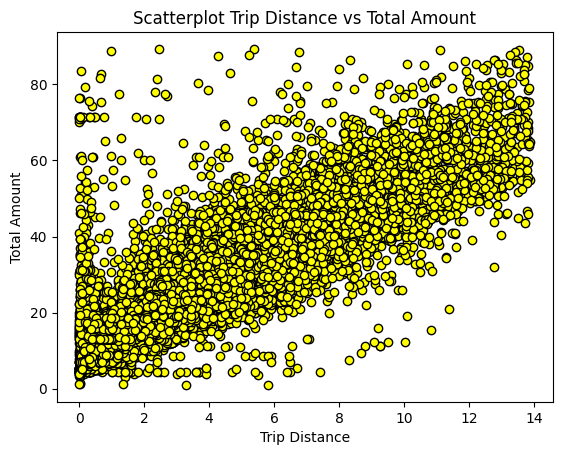

In [79]:
plt.figure()
plt.scatter(df_filtered['trip_distance'], df_filtered['total_amount'], color='yellow', edgecolor='black')
plt.xlabel('Trip Distance')
plt.ylabel('Total Amount')
plt.title('Scatterplot Trip Distance vs Total Amount')
plt.show()

2.5.2 melihat korelasi antara trip dengan biaya

In [80]:
#melihat korelasi trip_distance dengan total_amount
from scipy.stats import spearmanr

corr, p_value = spearmanr(df_filtered['trip_distance'], df_filtered['total_amount'])

print("Spearman Correlation:", corr)
print("P-value: {:.2e}".format(p_value))

Spearman Correlation: 0.8880142143104042
P-value: 0.00e+00


In [81]:
df_filtered['borough_flag'] = df_filtered['PU_borough'].apply(
    lambda x: 'Manhattan' if x == 'Manhattan' else 'Non-Manhattan'
)

In [82]:
df_filtered.head()
df_filtered['borough_flag'].value_counts()

borough_flag
Manhattan        38101
Non-Manhattan    25423
Name: count, dtype: int64

2.5.3 Melihat distribusi jarak di setiap borough

In [83]:
#Preparasi Stacked bar plot per borough berdasarkan flag_distance
breakdown = df_filtered.groupby(['PU_borough', 'flag_distance']).size().unstack(fill_value=0)
breakdown_pct = breakdown.div(breakdown.sum(axis=1), axis=0) * 100

# Bulatkan 2 desimal
breakdown_pct = breakdown_pct.round(2)
display(breakdown)
display(breakdown_pct)

flag_distance,high distance,low distance,moderate distance,very low distance
PU_borough,,,,
Bronx,70,328,315,139
Brooklyn,572,3710,2909,1078
Manhattan,951,22935,7874,6341
Queens,780,8142,4473,2859
Staten Island,1,2,3,3
Unknown,3,6,10,20


flag_distance,high distance,low distance,moderate distance,very low distance
PU_borough,,,,
Bronx,8.22,38.50,36.97,16.31
Brooklyn,6.92,44.87,35.18,13.04
Manhattan,2.50,60.20,20.67,16.64
Queens,4.80,50.09,27.52,17.59
Staten Island,11.11,22.22,33.33,33.33
Unknown,7.69,15.38,25.64,51.28


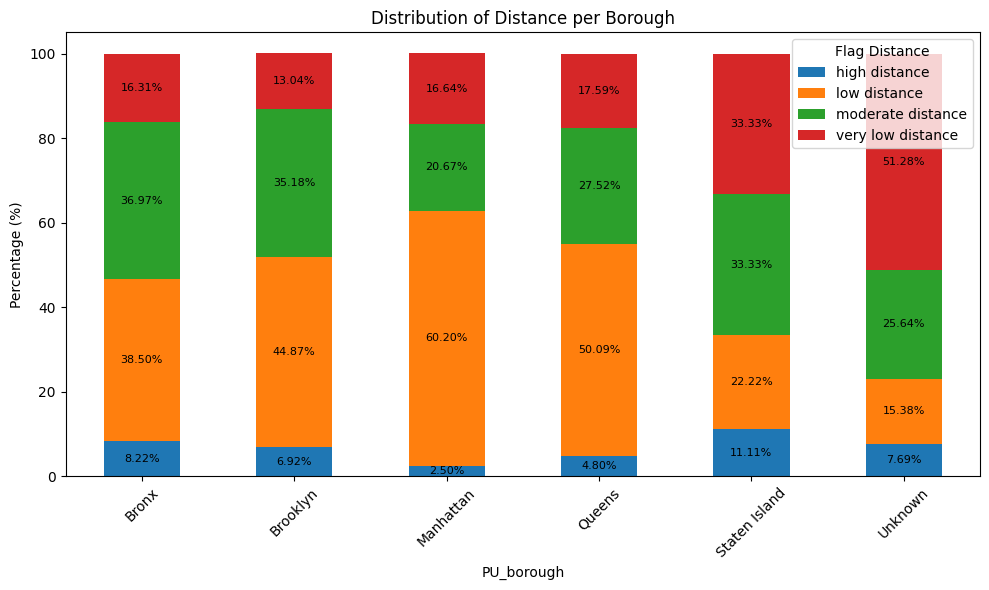

In [84]:
#Stacked bar plot demand borough percentage by flag_distance

ax = breakdown_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.ylabel('Percentage (%)')
plt.title('Distribution of Distance per Borough')
plt.legend(title='Flag Distance')

plt.xticks(rotation=45)
plt.tight_layout()

for i in range(len(breakdown_pct)):
    cumulative = 0
    for col in breakdown_pct.columns:
        value = breakdown_pct.iloc[i][col]
        
        if value > 0:  # biar ga numpuk label kecil banget
            ax.text(
                i,
                cumulative + value / 2,
                f"{value:.2f}%",
                ha='center',
                va='center',
                fontsize=8
            )
        cumulative += value

In [85]:
df_filtered['flag_distance'].value_counts()

flag_distance
low distance         35123
moderate distance    15584
very low distance    10440
high distance         2377
Name: count, dtype: int64

2.5.4 Melihat proporsi jarak di Manhattan

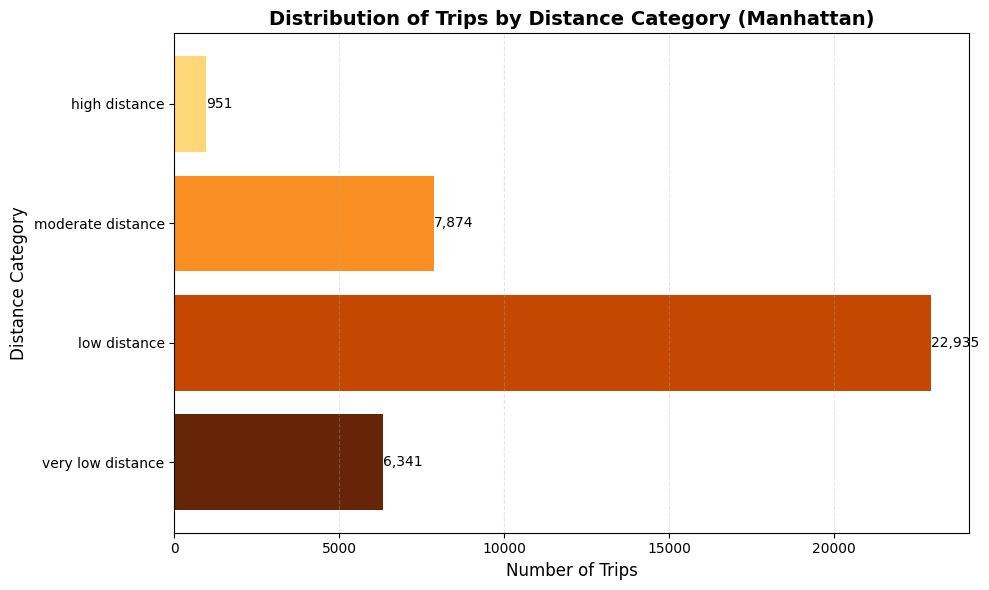

In [86]:
import matplotlib.pyplot as plt
import numpy as np

# Filter Manhattan
df_manhattan = df_filtered[df_filtered['borough_flag'] == 'Manhattan']

# Hitung jumlah per kategori
distance_counts = df_manhattan['flag_distance'].value_counts()

# Tentukan urutan kategori
order = [
    'very low distance',
    'low distance',
    'moderate distance',
    'high distance',
]

# Reindex sesuai urutan (dan isi 0 kalau ada yang kosong)
distance_counts = distance_counts.reindex(order).fillna(0)

plt.figure(figsize=(10,6))

# Gradasi kuning tua -> terang
colors = plt.cm.YlOrBr(np.linspace(1, 0.3, len(distance_counts)))

bars = plt.barh(
    distance_counts.index,
    distance_counts.values,
    color=colors
)

# Label angka
for i, v in enumerate(distance_counts.values):
    plt.text(v, i, f"{int(v):,}", va='center')

# Axis & title
plt.xlabel('Number of Trips', fontsize=12)
plt.ylabel('Distance Category', fontsize=12)
plt.title('Distribution of Trips by Distance Category (Manhattan)', fontsize=14, weight='bold')

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [87]:
df_manhattan['flag_distance'].value_counts()

flag_distance
low distance         22935
moderate distance     7874
very low distance     6341
high distance          951
Name: count, dtype: int64

## 2.6 Melihat kecenderungan customer hail atau  pesan online serta revenue harian

In [88]:
df_filtered['trip_type_desc'].value_counts()

trip_type_desc
Street-hail    62764
Dispatch         760
Name: count, dtype: int64

In [89]:
df_filtered_nonmanhattan = df_filtered.loc[df_filtered['borough_flag']=='Non-Manhattan', : ]
df_filtered_nonmanhattan['trip_type_desc'].value_counts()

trip_type_desc
Street-hail    24829
Dispatch         594
Name: count, dtype: int64

2.6.1 menambah kolom hari (Missing column)

In [90]:
# Melihat pola aktifitas berdasarkan weekend atau weekday

df_filtered['lpep_pickup_datetime'] = pd.to_datetime(df_filtered['lpep_pickup_datetime'])
df_filtered['lpep_dropoff_datetime'] = pd.to_datetime(df_filtered['lpep_dropoff_datetime'])

# Mapping hari
hari_map = {
    'Monday': 'Senin',
    'Tuesday': 'Selasa',
    'Wednesday': 'Rabu',
    'Thursday': 'Kamis',
    'Friday': 'Jumat',
    'Saturday': 'Sabtu',
    'Sunday': 'Minggu'
}

# Pickup day
df_filtered['pickup_day'] = df_filtered['lpep_pickup_datetime'].dt.day_name().map(hari_map)

# Dropoff day
df_filtered['dropoff_day'] = df_filtered['lpep_dropoff_datetime'].dt.day_name().map(hari_map)

2.6.2 Mengelompokan weekend dan weekday

In [91]:
# Pickup flag
df_filtered['pickup_flag_day'] = df_filtered['lpep_pickup_datetime'].dt.weekday.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

# Dropoff flag
df_filtered['dropoff_flag_day'] = df_filtered['lpep_dropoff_datetime'].dt.weekday.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

In [92]:
df_filtered.columns

df_filtered['pickup_day'].value_counts()

pickup_day
Selasa    10474
Kamis      9493
Jumat      9344
Senin      9327
Rabu       9232
Sabtu      7920
Minggu     7734
Name: count, dtype: int64

In [93]:
# Merapikan kolom
new_order = ['VendorID', 'lpep_pickup_datetime',  'pickup_day', 'pickup_flag_day', 
             'lpep_dropoff_datetime','dropoff_day','dropoff_flag_day',
       'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'PU_Zone',
       'PU_borough', 'borough_flag', 'PU_service_zone', 'DOLocationID',
       'DO_Zone', 'DO_borough', 'DO_service_zone', 'passenger_count',
       'trip_distance', 'flag_distance', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'payment_type', 'trip_type', 'congestion_surcharge', 'RateCode_desc',
       'payment_type_desc', 'trip_type_desc'
       ]

df_filtered = df_filtered[new_order]

df_filtered.head()

,VendorID,lpep_pickup_datetime,pickup_day,pickup_flag_day,lpep_dropoff_datetime,dropoff_day,dropoff_flag_day,store_and_fwd_flag,RatecodeID,PULocationID,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,RateCode_desc,payment_type_desc,trip_type_desc
0,2,2023-01-01 00:26:10,Minggu,Weekend,2023-01-01 00:37:11,Minggu,Weekend,N,1.0,166,...,4.03,0.0,1.0,24.18,1.0,1.0,2.75,Standard rate,Credit card,Street-hail
1,2,2023-01-01 00:51:03,Minggu,Weekend,2023-01-01 00:57:49,Minggu,Weekend,N,1.0,24,...,2.64,0.0,1.0,15.84,1.0,1.0,0.00,Standard rate,Credit card,Street-hail
3,1,2023-01-01 00:13:14,Minggu,Weekend,2023-01-01 00:19:03,Minggu,Weekend,N,1.0,41,...,1.70,0.0,1.0,10.20,1.0,1.0,0.00,Standard rate,Credit card,Street-hail
4,1,2023-01-01 00:33:04,Minggu,Weekend,2023-01-01 00:39:02,Minggu,Weekend,N,1.0,41,...,0.00,0.0,1.0,8.00,1.0,1.0,0.00,Standard rate,Credit card,Street-hail
5,2,2023-01-01 00:53:31,Minggu,Weekend,2023-01-01 01:11:04,Minggu,Weekend,N,1.0,41,...,0.00,0.0,1.0,22.95,2.0,1.0,2.75,Standard rate,Cash,Street-hail


2.6.3 Melihat revenue harian

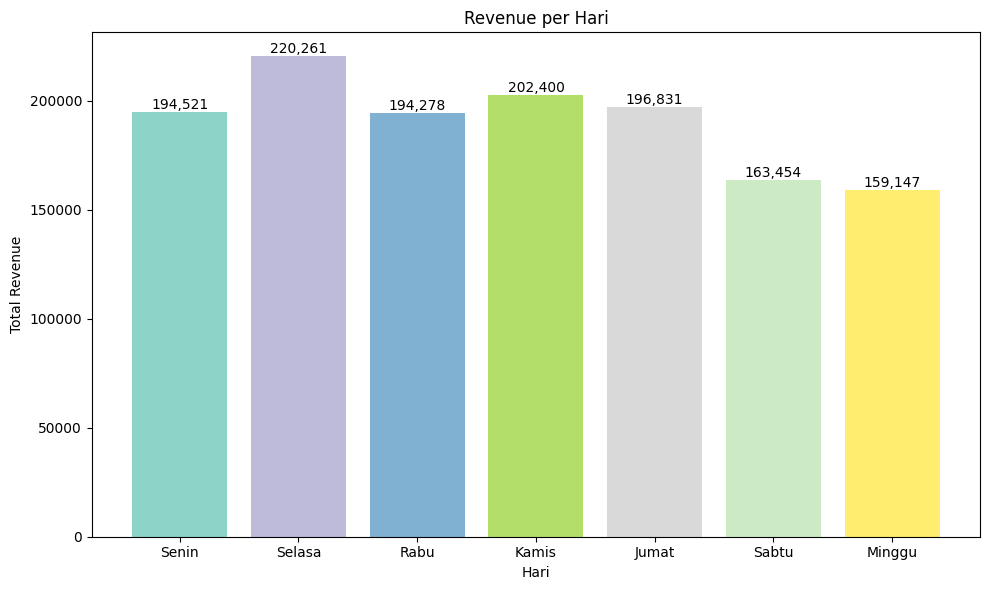

In [94]:
revenue_by_day = (
    df_filtered
    .groupby('pickup_day')['total_amount']
    .sum()
    .reset_index()
)

order_hari = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']

revenue_by_day['pickup_day'] = pd.Categorical(
    revenue_by_day['pickup_day'],
    categories=order_hari,
    ordered=True
)

revenue_by_day = revenue_by_day.sort_values('pickup_day')

plt.figure(figsize=(10,6))

# Generate warna berbeda (gradasi biar lebih clean)
colors = plt.cm.Set3(np.linspace(0, 1, len(revenue_by_day)))

bars = plt.bar(
    revenue_by_day['pickup_day'],
    revenue_by_day['total_amount'],
    color=colors
)

plt.xlabel('Hari')
plt.ylabel('Total Revenue')
plt.title('Revenue per Hari')

# Label angka
for i, v in enumerate(revenue_by_day['total_amount']):
    plt.text(i, v, f"{v:,.0f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [95]:
df_filtered.columns

Index(['VendorID', 'lpep_pickup_datetime', 'pickup_day', 'pickup_flag_day',
       'lpep_dropoff_datetime', 'dropoff_day', 'dropoff_flag_day',
       'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'PU_Zone',
       'PU_borough', 'borough_flag', 'PU_service_zone', 'DOLocationID',
       'DO_Zone', 'DO_borough', 'DO_service_zone', 'passenger_count',
       'trip_distance', 'flag_distance', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'payment_type', 'trip_type', 'congestion_surcharge', 'RateCode_desc',
       'payment_type_desc', 'trip_type_desc'],
      dtype='object')

2.6.4 melihat perbandingan luar dan dalam Manhattan di setiap harinya

C:\Users\Fauzan Hanindyawan Y\AppData\Local\Temp\ipykernel_16780\639435748.py:97: UserWarning: Glyph 128661 (\N{TAXI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Fauzan Hanindyawan Y\miniconda3\envs\jcdsbsdpm32\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128661 (\N{TAXI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


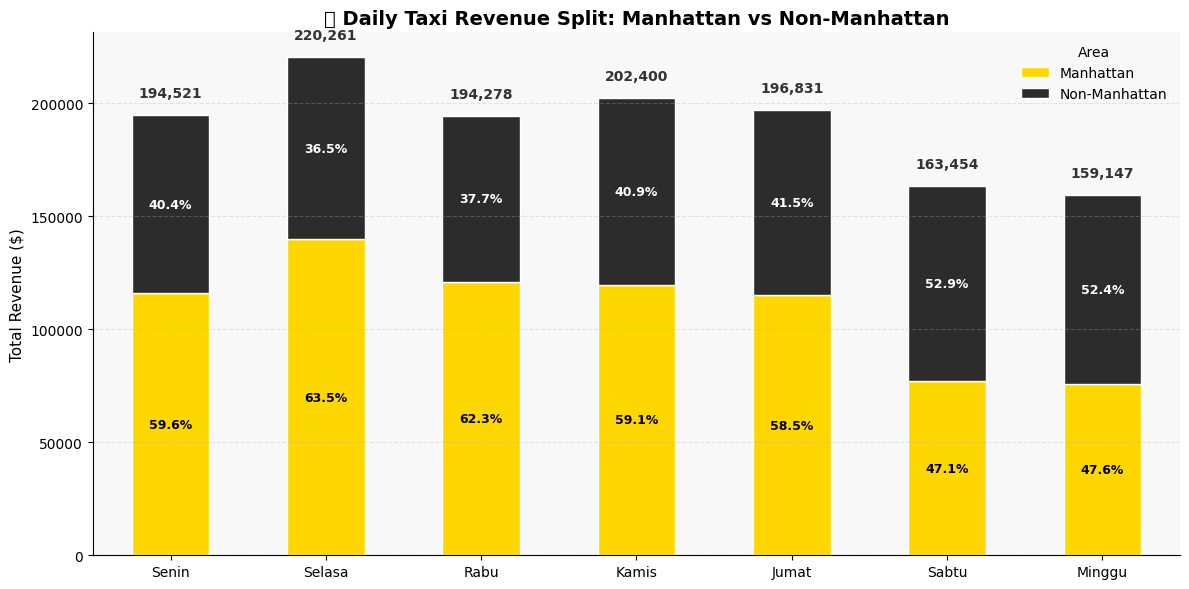

In [96]:
revenue_day_borough = (
    df_filtered
    .groupby(['pickup_day', 'borough_flag'])['total_amount']
    .sum()
    .unstack()
)

# Total revenue per hari
totals = revenue_day_borough.sum(axis=1)

# Persentase per segmen
revenue_pct = revenue_day_borough.div(totals, axis=0) * 100

# Persentase per segmen
revenue_pct = revenue_day_borough.div(totals, axis=0) * 100

order_hari = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']

revenue_day_borough = revenue_day_borough.reindex(order_hari)


# Warna khas taxi NYC
colors = {
    'Manhattan': '#FFD700',        # kuning taxi
    'Non-Manhattan': '#2C2C2C'     # hitam/abu gelap
}

fig, ax = plt.subplots(figsize=(12,6))

# Plot stacked bar dengan warna custom
revenue_day_borough.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[colors.get(col, '#999999') for col in revenue_day_borough.columns],
    edgecolor='white'
)

# Background & grid biar clean
ax.set_facecolor('#F8F8F8')
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Tambahkan persentase di tengah bar
for i, day in enumerate(revenue_day_borough.index):
    cumulative = 0
    for col in revenue_day_borough.columns:
        value = revenue_day_borough.loc[day, col]
        pct = revenue_pct.loc[day, col]

        if value > 0:
            y_pos = cumulative + value / 2

            ax.text(
                i,
                y_pos,
                f"{pct:.1f}%",
                ha='center',
                va='center',
                fontsize=9,
                fontweight='bold',
                color='black' if col == 'Manhattan' else 'white'
            )

            cumulative += value

# Tambahkan total di atas bar
for i, day in enumerate(revenue_day_borough.index):
    total_value = totals.loc[day]

    ax.text(
        i,
        total_value + (totals.max() * 0.03),
        f"{total_value:,.0f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )

# Styling tambahan
plt.title('🚕 Daily Taxi Revenue Split: Manhattan vs Non-Manhattan',
          fontsize=14, fontweight='bold')

plt.xlabel('')
plt.ylabel('Total Revenue ($)', fontsize=11)

plt.xticks(rotation=0)

# Legend lebih clean
plt.legend(title='Area', frameon=False)

# Hilangkan border atas & kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [97]:
df_weekend = df_filtered.loc[df_filtered['pickup_flag_day'] == 'Weekend', : ]
df_weekend.groupby('PU_borough')['lpep_pickup_datetime'].count().sort_values(ascending=False)

PU_borough
Manhattan        8042
Queens           4504
Brooklyn         2896
Bronx             197
Unknown            14
Staten Island       1
Name: lpep_pickup_datetime, dtype: int64

In [98]:
df_weekend = df_filtered.loc[df_filtered['pickup_flag_day'] == 'Weekend', :]

revenue_weekend_borough = (
    df_weekend
    .groupby('PU_borough')['total_amount']
    .sum()
    .sort_values(ascending=False)
)

revenue_weekend_borough

PU_borough
Manhattan        152758.00
Queens            93837.45
Brooklyn          71404.10
Bronx              4176.23
Unknown             393.10
Staten Island        31.55
Name: total_amount, dtype: float64

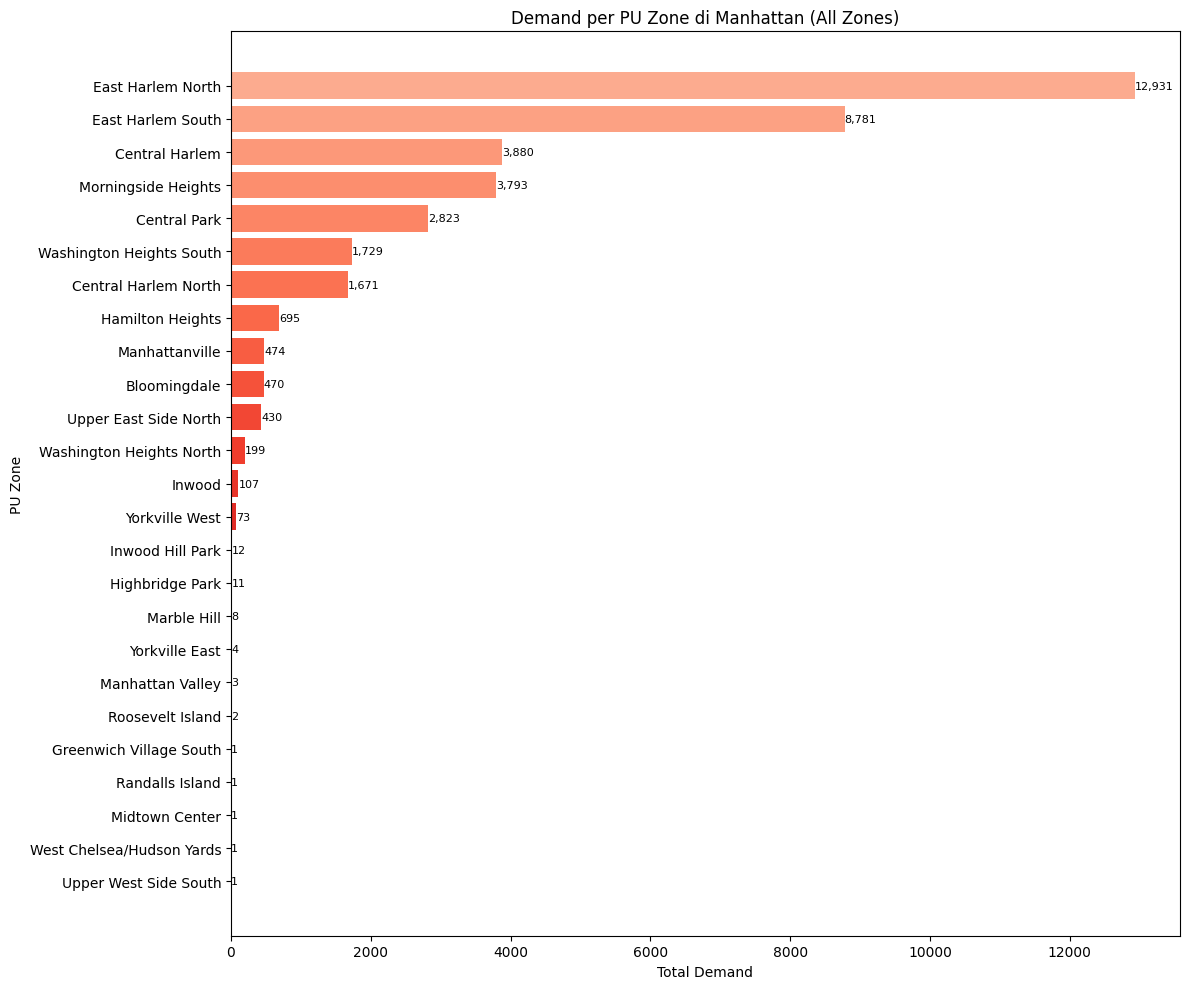

In [99]:
# Melihat sifat penumpang (behaviour)
# Daerah padat perkantoran di Manhattan
# Midtown Center
# Midtown East
# Midtown North
# Midtown South
# Garment District
# Murray Hill

df_manhattan = df_filtered.loc[df_filtered['borough_flag']=='Manhattan', : ]
df_manhattan['PU_Zone'].value_counts()

zone_counts = df_manhattan['PU_Zone'].value_counts()

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 10))  # lebih tinggi biar muat semua

colors = plt.cm.Reds(np.linspace(0.3, 1, len(zone_counts)))

bars = plt.barh(
    zone_counts.index,
    zone_counts.values,
    color=colors
)

plt.gca().invert_yaxis()

# Label angka
for i, v in enumerate(zone_counts.values):
    plt.text(v, i, f"{v:,}", va='center', fontsize=8)

plt.title('Demand per PU Zone di Manhattan (All Zones)')
plt.xlabel('Total Demand')
plt.ylabel('PU Zone')

plt.tight_layout()
plt.show()


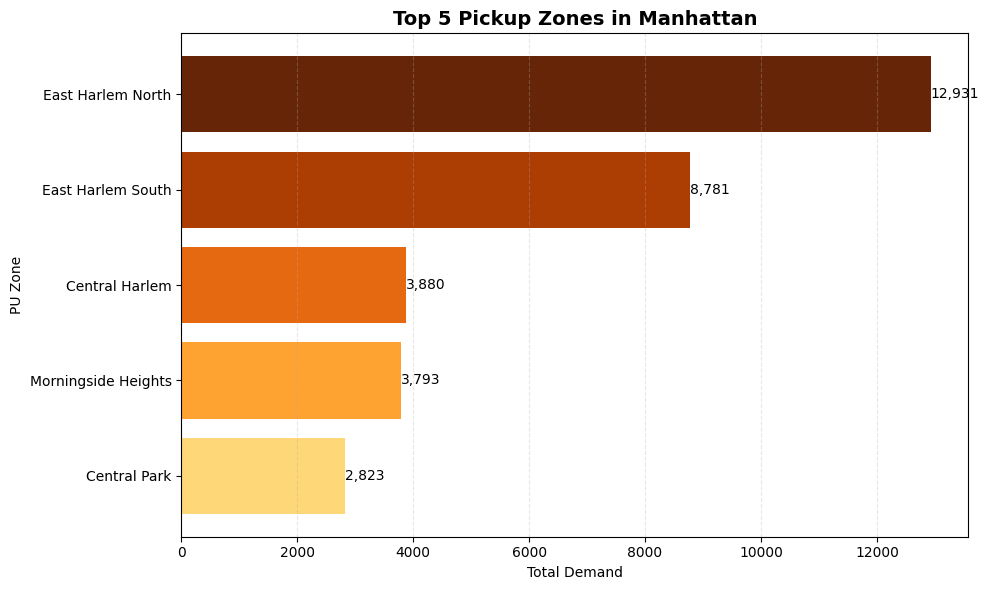

In [100]:
# Filter Manhattan
df_manhattan = df_filtered[df_filtered['borough_flag'] == 'Manhattan']

# Ambil Top 5 PU Zone
zone_counts = (
    df_manhattan['PU_Zone']
    .value_counts()
    .head(5)
    .sort_values()  # biar enak dibaca di barh
)

plt.figure(figsize=(10,6))

# Gradasi kuning (terang → lebih gelap untuk highlight)
colors = plt.cm.YlOrBr(np.linspace(0.3, 1, len(zone_counts)))

bars = plt.barh(
    zone_counts.index,
    zone_counts.values,
    color=colors
)

# Label angka
for i, v in enumerate(zone_counts.values):
    plt.text(v, i, f"{v:,}", va='center')

# Axis & title
plt.title('Top 5 Pickup Zones in Manhattan', fontsize=14, weight='bold')
plt.xlabel('Total Demand')
plt.ylabel('PU Zone')

# Grid halus
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

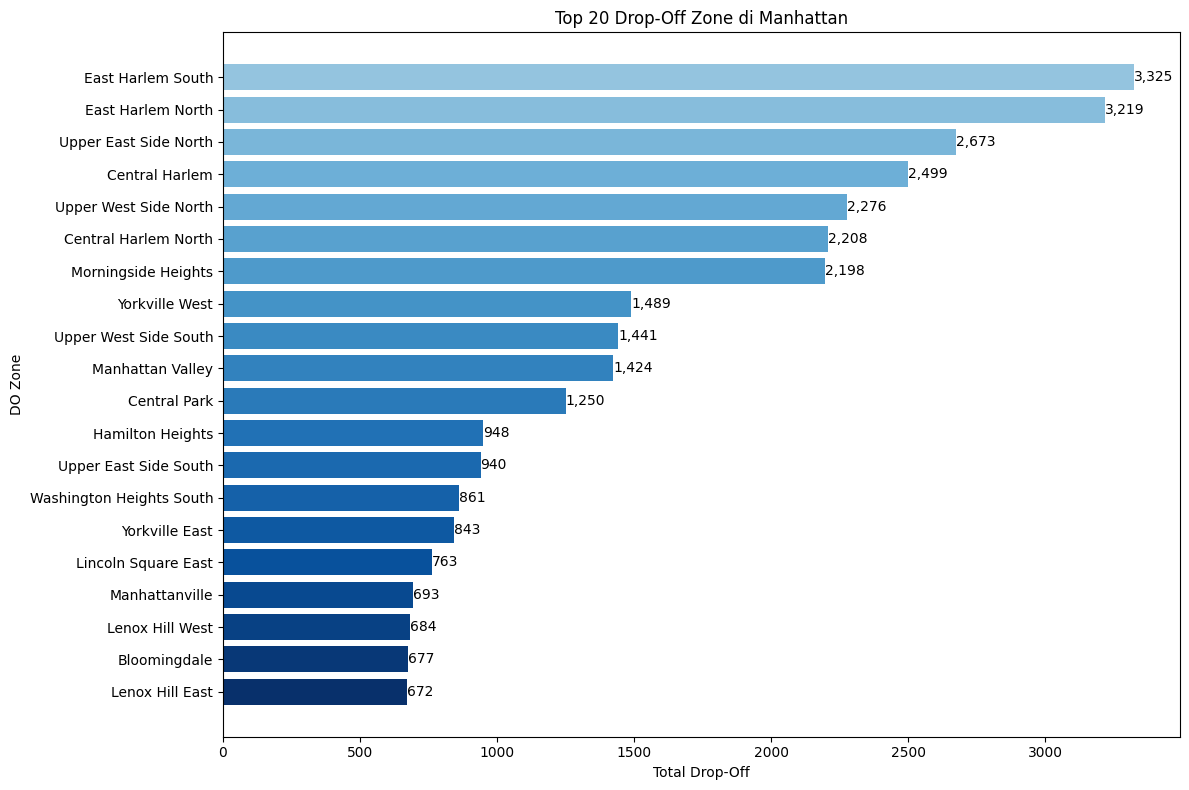

In [101]:
# Filter Manhattan
df_manhattan = df_filtered.loc[df_filtered['borough_flag'] == 'Manhattan', :].copy()

# Hitung DO Zone dan ambil top 20
zone_counts_do = df_manhattan['DO_Zone'].value_counts().head(20)

# Plot
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))  # sedikit lebih kecil karena cuma 20

colors = plt.cm.Blues(np.linspace(0.4, 1, len(zone_counts_do)))

bars = plt.barh(
    zone_counts_do.index,
    zone_counts_do.values,
    color=colors
)

plt.gca().invert_yaxis()

# Label angka
for i, v in enumerate(zone_counts_do.values):
    plt.text(v, i, f"{v:,}", va='center')

plt.title('Top 20 Drop-Off Zone di Manhattan')
plt.xlabel('Total Drop-Off')
plt.ylabel('DO Zone')

plt.tight_layout()
plt.show()

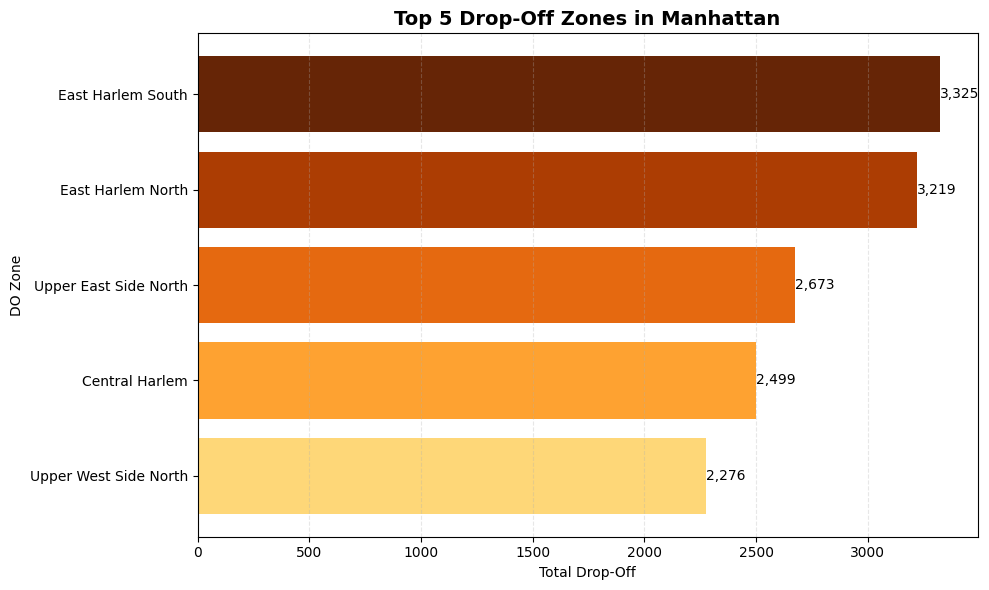

In [102]:
# Filter Manhattan
df_manhattan = df_filtered.loc[df_filtered['borough_flag'] == 'Manhattan', :].copy()

# Ambil Top 5 DO Zone
zone_counts_do = (
    df_manhattan['DO_Zone']
    .value_counts()
    .head(5)
    .sort_values()  # biar enak dibaca di barh
)

# Plot
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

# Gradasi kuning
colors = plt.cm.YlOrBr(np.linspace(0.3, 1, len(zone_counts_do)))

bars = plt.barh(
    zone_counts_do.index,
    zone_counts_do.values,
    color=colors
)

# Label angka
for i, v in enumerate(zone_counts_do.values):
    plt.text(v, i, f"{v:,}", va='center')

# Judul & axis
plt.title('Top 5 Drop-Off Zones in Manhattan', fontsize=14, weight='bold')
plt.xlabel('Total Drop-Off')
plt.ylabel('DO Zone')

# Grid halus
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [103]:
len(df_filtered['PU_Zone'].value_counts())

194

# 2.7 Trip diluar Manhattan

In [104]:
df_filtered_nonmanhattan.head()
df_filtered_nonmanhattan.columns

Index(['VendorID', 'lpep_pickup_datetime', 'lpep_dropoff_datetime',
       'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'PU_Zone',
       'PU_borough', 'PU_service_zone', 'DOLocationID', 'passenger_count',
       'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount', 'payment_type',
       'trip_type', 'congestion_surcharge', 'RateCode_desc',
       'payment_type_desc', 'trip_type_desc', 'DO_borough', 'DO_Zone',
       'DO_service_zone', 'trip_detail', 'pickup_hour', 'dropoff_hour',
       'demand_flag', 'flag_distance', 'borough_flag'],
      dtype='object')

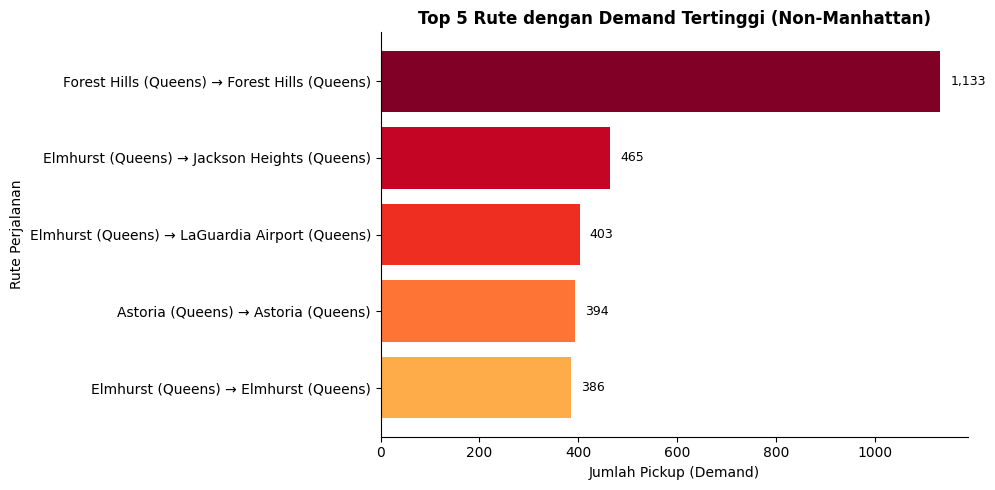

In [105]:
# Buat kolom trip_detail
df_filtered_nonmanhattan['trip_detail'] = (
    df_filtered_nonmanhattan['PU_Zone'].astype(str) + ' (' + df_filtered_nonmanhattan['PU_borough'].astype(str) + ')' +
    ' → ' +
    df_filtered_nonmanhattan['DO_Zone'].astype(str) + ' (' + df_filtered_nonmanhattan['DO_borough'].astype(str) + ')'
)

# Hitung demand
trip_demand = (
    df_filtered_nonmanhattan
    .groupby('trip_detail')
    .size()
    .reset_index(name='demand')
)

# Ambil Top 5
top5_trip = (
    trip_demand
    .sort_values(by='demand', ascending=False)
    .head(5)
    .sort_values(by='demand')  # penting untuk barh
)

# Plot
plt.figure(figsize=(10, 5))

# Warna gradasi (semakin tinggi semakin merah)
colors = plt.cm.YlOrRd(np.linspace(0.4, 1, len(top5_trip)))

bars = plt.barh(
    top5_trip['trip_detail'],
    top5_trip['demand'],
    color=colors
)

# Label angka (lebih rapi & ada jarak)
for i, v in enumerate(top5_trip['demand']):
    plt.text(v + 20, i, f"{v:,}", va='center', fontsize=9)

# Judul & label
plt.title('Top 5 Rute dengan Demand Tertinggi (Non-Manhattan)', fontsize=12, weight='bold')
plt.xlabel('Jumlah Pickup (Demand)')
plt.ylabel('Rute Perjalanan')

# Hilangkan garis yang tidak perlu biar clean
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### **Kesimpulan Sementara**

1. **Di dalam kota New York tidak terdapat layanan Ojek Online seperti di Indonesia karena :**

    a. Regulasi yang ketat

    b. Faktor cuaca dan Keselamatan (salju dan angin kencang)

    c. Budaya dan Infrastruktur (Jalan di kota khususnya Manhattan sangatlah besar)

    d. Karena tidak ada Ojol, maka masyarakat yang tidak terlalu ingin jalan kaki, lebih banyak menggunakan Yellow Taxi (TLC)

    e. Budaya bersepeda dan Jalan kaki (New York khususnya Manhattan dan Brooklyn sangat Walkable jika dbandingkan Borough lain)

    f. Borough lain seperti Bronx, Queens dan Staten Island itu tidak terlalu Walkable namun taxi di New York justru terkonsentrasi di Manhattan
    
    g. Bahkan di Staten Island saking sulitnya jalan kaki, lebih banyak yang memiliki mobil pribadi

2. **Trip paling banyak didominasi didalam Borough Manhattan ke Manhattan, dengan rincian PU Zone - DO Zone sebagai berikut :**

    a. East Harlem North (Manhattan) ke East Harlem South (Manhattan) :

        - Terjadi karena merupakan Area residensial yang padat (banyak Apartemen)
        - Tidak semua blok itu dekat ke transportasi umum
    
    b. Contoh yang queens, perjalanan tertinggi no 4 justru didominasi oleh Queens : 

        - Forest Hills (Queens) ke Forest Hills (Queens) dikarenakan Queens merupakan Zona residensial besar
        - Mirip seperti Jakarta Timur/Jakarta Barat dan tidak se walkable Manhattan atau Brooklyn sehingga banyak yang memilih           menggunakan Taxi
        - Local Activity tinggi, dimana Forest Hills memiliki banyak restoran, supermarket dan gym

3. ** Pada hari kerja revenue didominasi oleh Manhattan, namun justru di Weekend (Sabtu dan Minggu) revenue lebih didominasi Outer Manhattan** :

    a. Dapat disimpulkan bahwa Manhattan memang zona para pekerja terbukti komposisi revenue menurun saat hari libur
    b. Meningkatnya demand diluar Manhattan di Weekend menjadi pertanda bahwa demand pelanggan menggunakan taxi cukup tinggi diluar Manhattan khususnya di daerah Queens

4. ** Rush Hour di Manhattan (demand tinggi) terjadi justru saat jam pulang kerja (14.00 s.d. 20.00 Waktu setempat) 
    a. Di pagi hari yang seharusnya Rush Hour penggunaan taxi tidak signifikan karena Mayoritas menggunakan angkutan umum seperti Subway atau Bus

    b. Demand taxi sebaiknya tersedia saat jam Rush Hour di Manhattan

5. ** Behaviour pengguna taxi NYC justru bukan dari dan ke wilayah perkantoran di Manhattan **
    - di Manhattan wilayah padat perkantoran adalah daerah Midtown, Garment District dan Murray Hill
    - namun justru yang banyak adalah wilayah residential (residential demand) itulah kenapa jarak didominasi jarak pendek-menengah
    - untuk aktivitas-aktivitas belanja, sekolah, rumah sakit dan aktivitas harian
    - kalaupun untuk pekerja, taxi digunakan untuk ke/dari daerah halte stasiun rumah ke stasiun atau sebaliknya
    - di Manhattan diduga orang malas pakai mobil karena macet

6. **Sistem seperti:**

    - New York City Subway
    - Bus kota
    - Ini adalah:
        - paling murah
        - paling cepat (hindari macet)
        - paling praktis
        - Mayoritas pekerja Manhattan:
            pakai subway untuk commuting harian 

7. **Taxi = pelengkap, bukan utama**

    - Taxi (yellow cab / Uber / Lyft):

        Digunakan untuk:

        - last mile (rumah ↔ stasiun)
        - kondisi tertentu:
        - hujan
        - telat
        - malam hari
        - business travel (tapi tidak mayoritas)

8. Mobil pribadi sangat Minoritas di Manhattan karena tidak convenience (Macet dan Parkir Mahal)

9. Perbandingan pemesanan online sangat sedikit jiga dibandingkan dengan Street-Hail :

    - Untuk aplikasi online bersaing dengan Uber

    - Regulasi online yang sulit

    - Pengemudi terkonsentrasi di Borough padat penduduk yaitu Manhattan, yang lebih banyak didominasi oleh trip spontan dan jarak pendek

    - bisa ditingkatkan pengembangan aplikasi pemesanan online dengan tarif pasti untuk diluar Borough Manhattan, dengan harapan bersaing dengan Uber untuk taxi online dan revenue tidak hanya terkonsentrasi di Manhattan dimana borough seperti Queens dan Brooklyn juga dinilai cukup padat penduduk





2.7.1 Perbandingan antara Manhattan dengan Non Manhattan

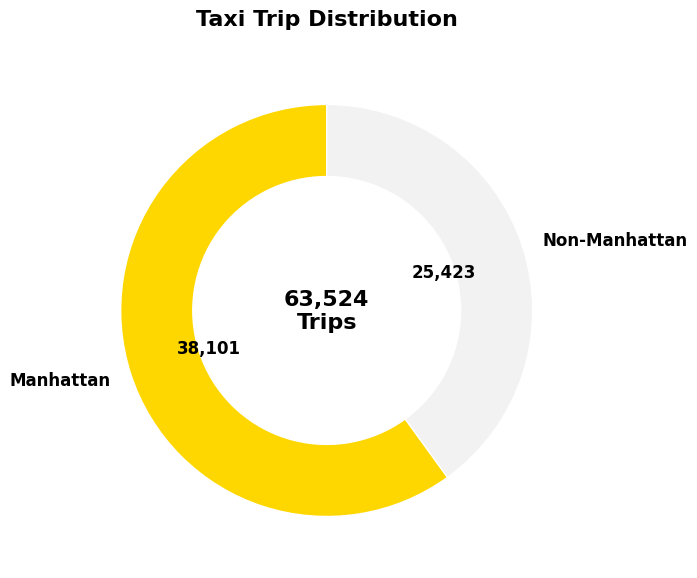

In [106]:
# Data
borough_counts = df_filtered['borough_flag'].value_counts()

# Warna tetap
colors = ['#FFD700', '#F2F2F2']  # kuning & abu sangat terang

# Fungsi untuk count
def autopct_format(values):
    def inner(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{val:,}'
    return inner

# Plot
plt.figure(figsize=(7,7))

wedges, texts, autotexts = plt.pie(
    borough_counts,
    labels=borough_counts.index,
    autopct=autopct_format(borough_counts),
    startangle=90,
    colors=colors,
    wedgeprops={'width': 0.35, 'edgecolor': 'white'},  # donut effect
    textprops={'fontsize': 12, 'weight': 'bold'}
)

# Center text (TOTAL)
total = borough_counts.sum()
plt.text(0, 0, f'{total:,}\nTrips',
         ha='center', va='center',
         fontsize=16, weight='bold')

# Judul (clean & modern)
plt.title('Taxi Trip Distribution',
          fontsize=16, weight='bold', pad=20)

plt.tight_layout()
plt.show()

In [107]:
df_filtered.columns

Index(['VendorID', 'lpep_pickup_datetime', 'pickup_day', 'pickup_flag_day',
       'lpep_dropoff_datetime', 'dropoff_day', 'dropoff_flag_day',
       'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'PU_Zone',
       'PU_borough', 'borough_flag', 'PU_service_zone', 'DOLocationID',
       'DO_Zone', 'DO_borough', 'DO_service_zone', 'passenger_count',
       'trip_distance', 'flag_distance', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'payment_type', 'trip_type', 'congestion_surcharge', 'RateCode_desc',
       'payment_type_desc', 'trip_type_desc'],
      dtype='object')

# 2.8 Missing Out Analysis

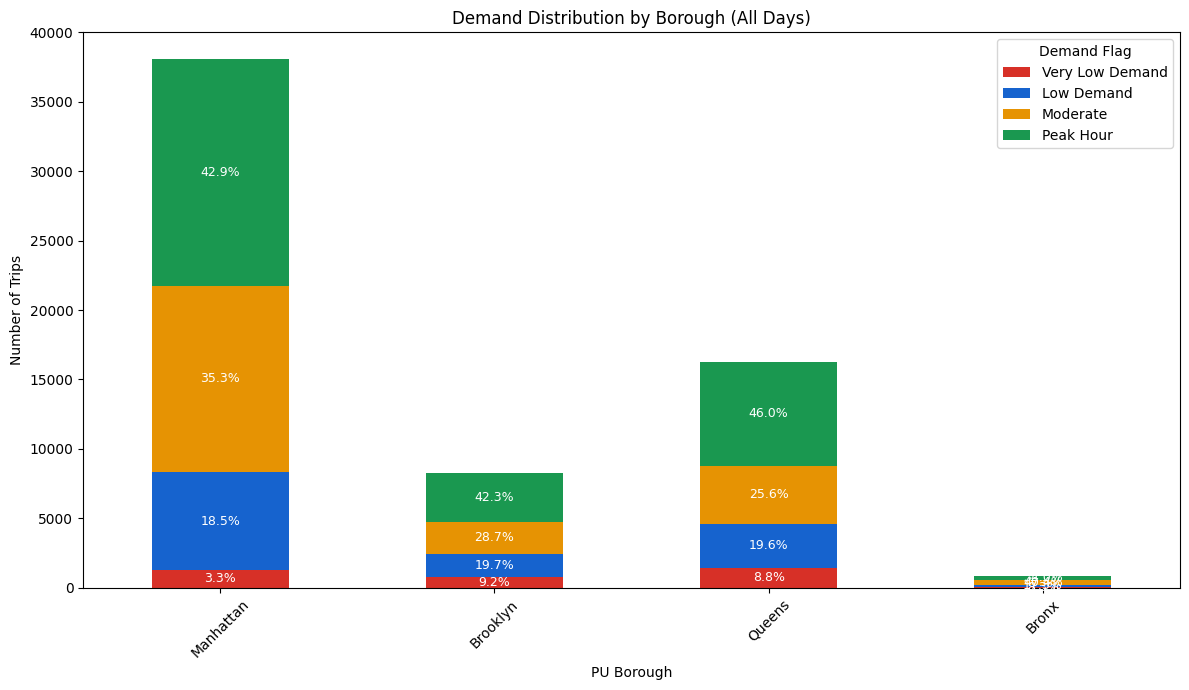

In [108]:

# 1. Copy full data (tanpa filter weekend)
df_all = df_filtered.copy()

# 2. Extract jam
df_all['pickup_hour'] = df_all['lpep_pickup_datetime'].dt.hour

# 3. Hitung jumlah trip per jam
hour_count = (
    df_all
    .groupby('pickup_hour')['lpep_pickup_datetime']
    .count()
    .reset_index(name='num_trips')
)

# 4. Hitung quantile
Q1 = hour_count['num_trips'].quantile(0.25)
Q2 = hour_count['num_trips'].quantile(0.50)
Q3 = hour_count['num_trips'].quantile(0.75)

# 5. Fungsi segmentasi
def segment_demand(x):
    if x < Q1:
        return "Very Low Demand"
    elif Q1 <= x < Q2:
        return "Low Demand"
    elif Q2 <= x < Q3:
        return "Moderate"
    else:
        return "Peak Hour"

# 6. Apply ke hour_count
hour_count['demand_flag'] = hour_count['num_trips'].apply(segment_demand)

# 7. Mapping ke dataframe utama
df_all = df_all.merge(
    hour_count[['pickup_hour', 'demand_flag']],
    on='pickup_hour',
    how='left'
)

# 8. (Optional) Hapus borough tidak relevan
df_all = df_all[
    ~df_all['PU_borough'].isin(['Unknown', 'Staten Island'])
]

# 9. Aggregasi
breakdown = (
    df_all
    .groupby(['PU_borough', 'demand_flag'])['lpep_pickup_datetime']
    .count()
    .reset_index(name='count')
)

# 10. Pivot
breakdown = breakdown.pivot(
    index='PU_borough',
    columns='demand_flag',
    values='count'
).fillna(0)

# 11. Urutan kolom biar konsisten
breakdown = breakdown[
    ["Very Low Demand", "Low Demand", "Moderate", "Peak Hour"]
]

# Urutan borough yang diinginkan
order = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx']

# Reindex
breakdown = breakdown.reindex(order)

# Define warna sesuai demand_flag
color_map = {
    "Very Low Demand": "#d73027",   # merah
    "Low Demand": "#1663ce",        # oranye
    "Moderate": "#e69303",          # kuning
    "Peak Hour": "#1a9850"          # hijau
}

# Ambil warna sesuai urutan kolom
colors = [color_map[col] for col in breakdown.columns]

# Plot
ax = breakdown.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7),
    color=colors
)

# 13. Tambahkan persentase
breakdown_pct = breakdown.div(breakdown.sum(axis=1), axis=0) * 100

for i, borough in enumerate(breakdown.index):
    cumulative = 0
    for col in breakdown.columns:
        value = breakdown.loc[borough, col]
        pct = breakdown_pct.loc[borough, col]

        if value > 0 and pct > 3:
            ax.text(
                i,
                cumulative + value / 2,
                f"{pct:.1f}%",
                ha='center',
                va='center',
                fontsize=9,
                color='white'
            )
        cumulative += value

# Styling
plt.title('Demand Distribution by Borough (All Days)')
plt.xlabel('PU Borough')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.legend(title='Demand Flag')
plt.tight_layout()
plt.show()

In [109]:
df_filtered.columns

Index(['VendorID', 'lpep_pickup_datetime', 'pickup_day', 'pickup_flag_day',
       'lpep_dropoff_datetime', 'dropoff_day', 'dropoff_flag_day',
       'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'PU_Zone',
       'PU_borough', 'borough_flag', 'PU_service_zone', 'DOLocationID',
       'DO_Zone', 'DO_borough', 'DO_service_zone', 'passenger_count',
       'trip_distance', 'flag_distance', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'payment_type', 'trip_type', 'congestion_surcharge', 'RateCode_desc',
       'payment_type_desc', 'trip_type_desc'],
      dtype='object')

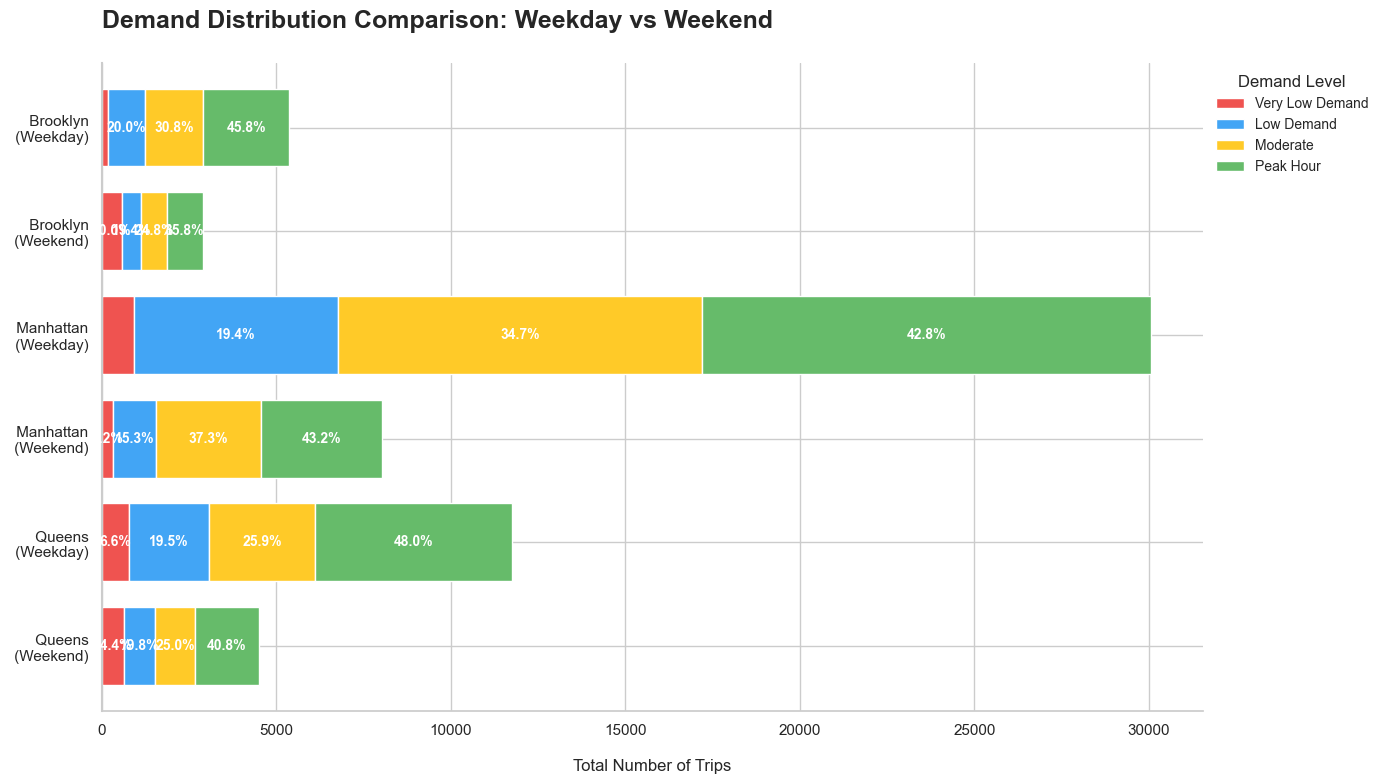

In [139]:
# 1. Persiapan Data & Pembersihan
df_all = df_filtered.copy()
df_all['pickup_hour'] = df_all['lpep_pickup_datetime'].dt.hour

# 2. Segmentasi Demand (Logika Quantile)
hour_count = df_all.groupby('pickup_hour')['lpep_pickup_datetime'].count().reset_index(name='num_trips')
Q1, Q2, Q3 = hour_count['num_trips'].quantile([0.25, 0.50, 0.75])

def segment_demand(x):
    if x < Q1: return "Very Low Demand"
    elif Q1 <= x < Q2: return "Low Demand"
    elif Q2 <= x < Q3: return "Moderate"
    else: return "Peak Hour"

hour_count['demand_flag'] = hour_count['num_trips'].apply(segment_demand)
df_all = df_all.merge(hour_count[['pickup_hour', 'demand_flag']], on='pickup_hour', how='left')

# 3. Filter Borough (Menghapus Bronx sesuai permintaan)
# Hanya menyisakan Manhattan, Brooklyn, dan Queens
target_boroughs = ['Manhattan', 'Brooklyn', 'Queens']
df_all = df_all[df_all['PU_borough'].isin(target_boroughs)]

# 4. Agregasi & Pivot
breakdown = (
    df_all
    .groupby(['PU_borough', 'pickup_flag_day', 'demand_flag'])
    .size()
    .unstack(fill_value=0)
)

# Urutan Kolom & Baris
cols_order = ["Very Low Demand", "Low Demand", "Moderate", "Peak Hour"]
breakdown = breakdown[cols_order]
breakdown = breakdown.reindex(target_boroughs, level=0)
breakdown = breakdown.reorder_levels(['PU_borough', 'pickup_flag_day']).sort_index(level=0, sort_remaining=False)

# 5. Styling Palet Warna (Dibuat lebih elegan/modern)
color_map = {
    "Very Low Demand": "#EF5350",   # Soft Red
    "Low Demand": "#42A5F5",        # Soft Blue
    "Moderate": "#FFCA28",          # Amber/Yellow
    "Peak Hour": "#66BB6A"          # Soft Green
}
colors = [color_map[col] for col in breakdown.columns]

# 6. Plotting
fig, ax = plt.subplots(figsize=(14, 8))
plt.rcParams['font.family'] = 'sans-serif' # Menggunakan font bersih

breakdown.plot(
    kind='barh', 
    stacked=True, 
    color=colors,
    ax=ax,
    edgecolor='white',
    linewidth=1,
    width=0.75
)

# 7. Penambahan Persentase dengan Logika Penempatan yang Lebih Rapi
breakdown_pct = breakdown.div(breakdown.sum(axis=1), axis=0) * 100

for i, (idx, row) in enumerate(breakdown.iterrows()):
    cumulative = 0
    for col in breakdown.columns:
        value = row[col]
        pct = breakdown_pct.loc[idx, col]
        
        if pct > 4:  # Hanya tampilkan jika porsi lebih dari 4%
            ax.text(
                cumulative + value / 2, # Posisi X (tengah segmen)
                i,                      # Posisi Y (indeks bar)
                f"{pct:.1f}%", 
                va='center', 
                ha='center', 
                fontsize=10, 
                color='white',
                fontweight='bold'
                # Baris textcoords dihapus karena ax.text tidak memerlukannya
            )
        cumulative += value

# 8. Sentuhan Akhir Estetika
ax.set_title('Demand Distribution Comparison: Weekday vs Weekend', fontsize=18, fontweight='bold', pad=25, loc='left')
ax.set_xlabel('Total Number of Trips', fontsize=12, labelpad=15)
ax.set_ylabel('') # Hapus label sumbu Y karena sudah jelas dari tick labels

# Mempercantik Label Y: Menggabungkan Borough dan Tipe Hari
labels = [f" {b}\n ({d})" for b, d in breakdown.index]
ax.set_yticklabels(labels, fontsize=11, fontweight='medium')

# Menghapus spine (garis tepi) yang tidak perlu
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)

# Legend yang lebih rapi
ax.legend(title='Demand Level', title_fontsize='12', fontsize='10', 
          bbox_to_anchor=(1.0, 1.0), loc='upper left', frameon=False)

plt.gca().invert_yaxis() # Biar Manhattan tetap di atas
plt.tight_layout()
plt.show()

2.8.1 Melihat Kecenderungan Payment Type terhadap pemberian tip

In [110]:
df_filtered.head()

,VendorID,lpep_pickup_datetime,pickup_day,pickup_flag_day,lpep_dropoff_datetime,dropoff_day,dropoff_flag_day,store_and_fwd_flag,RatecodeID,PULocationID,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,RateCode_desc,payment_type_desc,trip_type_desc
0,2,2023-01-01 00:26:10,Minggu,Weekend,2023-01-01 00:37:11,Minggu,Weekend,N,1.0,166,...,4.03,0.0,1.0,24.18,1.0,1.0,2.75,Standard rate,Credit card,Street-hail
1,2,2023-01-01 00:51:03,Minggu,Weekend,2023-01-01 00:57:49,Minggu,Weekend,N,1.0,24,...,2.64,0.0,1.0,15.84,1.0,1.0,0.00,Standard rate,Credit card,Street-hail
3,1,2023-01-01 00:13:14,Minggu,Weekend,2023-01-01 00:19:03,Minggu,Weekend,N,1.0,41,...,1.70,0.0,1.0,10.20,1.0,1.0,0.00,Standard rate,Credit card,Street-hail
4,1,2023-01-01 00:33:04,Minggu,Weekend,2023-01-01 00:39:02,Minggu,Weekend,N,1.0,41,...,0.00,0.0,1.0,8.00,1.0,1.0,0.00,Standard rate,Credit card,Street-hail
5,2,2023-01-01 00:53:31,Minggu,Weekend,2023-01-01 01:11:04,Minggu,Weekend,N,1.0,41,...,0.00,0.0,1.0,22.95,2.0,1.0,2.75,Standard rate,Cash,Street-hail


2.8.2 melihat distribusi tip_amount

In [111]:
# cek normalitas tip amount
from scipy.stats import shapiro

stat, p_value = shapiro(df_filtered['tip_amount'].sample(5000))  # sampling biar cepat

print("p-value:", p_value)

# data tidak terdistribusi normal

p-value: 2.7452999900077743e-69


2.8.3 histogram tip_amount

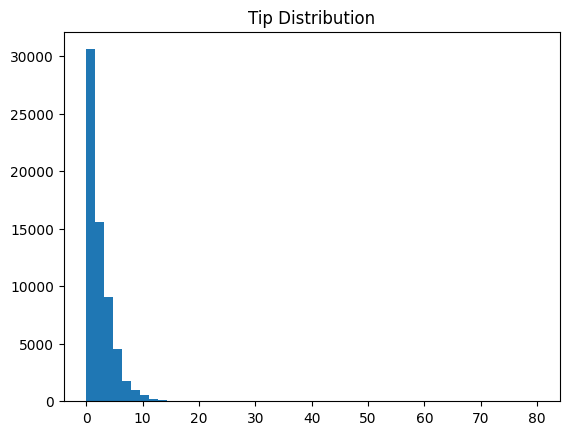

In [112]:
# coba dilakukan cek histogramnya (right skewed)
import matplotlib.pyplot as plt

plt.hist(df_filtered['tip_amount'], bins=50)
plt.title('Tip Distribution')
plt.show()


2.8.4 melihat amount dari tip

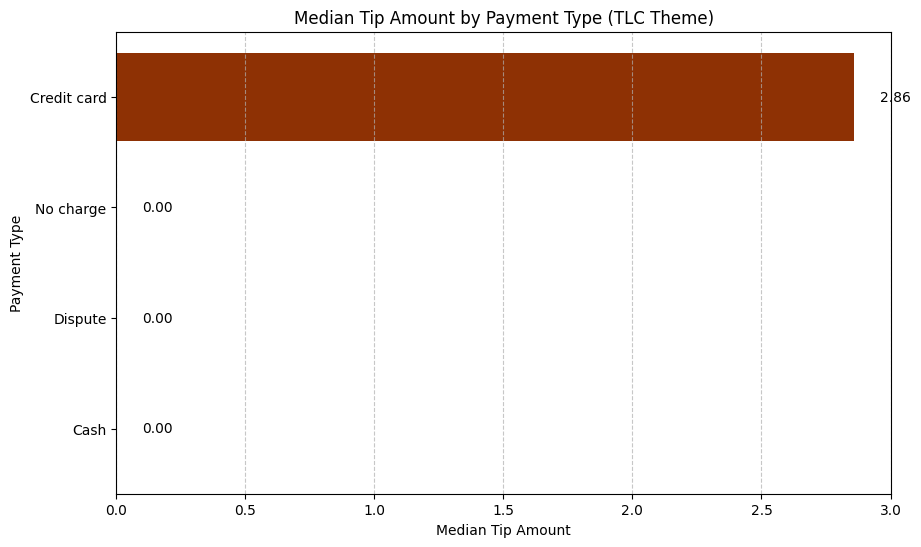

In [113]:
# Agregasi median tip per payment type
tip_by_payment = (
    df_filtered
    .groupby('payment_type_desc')['tip_amount']
    .median()
    .sort_values()
)

# Warna gradasi kuning (TLC style)
colors = plt.cm.YlOrBr(np.linspace(0.3, 0.9, len(tip_by_payment)))

# Plot
plt.figure(figsize=(10,6))
bars = plt.barh(tip_by_payment.index, tip_by_payment.values, color=colors)

# Tambahkan label di setiap bar
for i, v in enumerate(tip_by_payment.values):
    plt.text(v + 0.1, i, f'{v:.2f}', va='center')

plt.xlabel('Median Tip Amount')
plt.ylabel('Payment Type')
plt.title('Median Tip Amount by Payment Type (TLC Theme)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

In [114]:
from scipy.stats import kruskal

groups = [
    group['tip_amount'].values
    for name, group in df_filtered.groupby('payment_type_desc')
]

h_stat, p_value = kruskal(*groups)

print("H-statistic:", h_stat)
print("p-value:", p_value)

H-statistic: 37615.28011213881
p-value: 0.0


2.8.5 tip amount terhadap distance

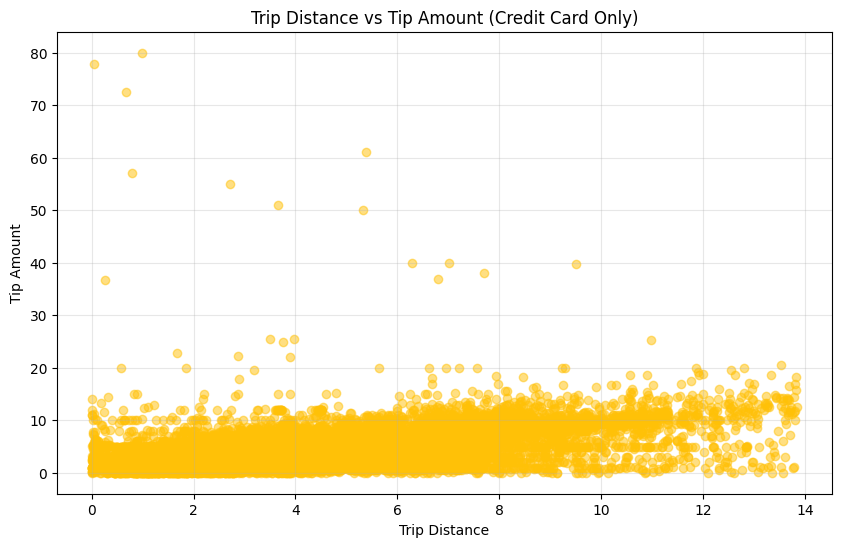

In [115]:

plt.figure(figsize=(10,6))

df_cc = df_filtered[
    (df_filtered['payment_type_desc'] == 'Credit card') &
    (df_filtered['trip_distance'] > 0) &
    (df_filtered['trip_distance'] < 50) &
    (df_filtered['tip_amount'] > 0)
]

plt.scatter(
    df_cc['trip_distance'],
    df_cc['tip_amount'],
    alpha=0.5,
    color='#FFC107'   # kuning ala TLC
)

plt.xlabel('Trip Distance')
plt.ylabel('Tip Amount')
plt.title('Trip Distance vs Tip Amount (Credit Card Only)')
plt.grid(alpha=0.3)

plt.show()

2.8.6 Lihat statistik nya

In [116]:
# Melihat korelasinya pakai spearman
from scipy.stats import spearmanr

corr, p_value = spearmanr(df_cc['trip_distance'], df_cc['tip_amount'])

print("Spearman Correlation:", corr)
print("p-value:", p_value) #korelasi kuat


Spearman Correlation: 0.6028737297847029
p-value: 0.0


# 2.9 Map Anaysis

In [117]:
# 1. Read lookup table dari Excel
lookup = pd.read_excel(
    'NYC TLC Trip Record.xlsx',
    sheet_name='Lookup Tabel'
)

# 1. Read lookup table dari Excel
lookup = pd.read_excel(
    'NYC TLC Trip Record.xlsx',
    sheet_name='Lookup Tabel'
)

# 2. Merge ke df_filtered (join berdasarkan PULocationID)
df_filtered = df_filtered.merge(
    lookup[['LocationID', 'lattitude_zone', 'longitude_zone']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

# 3. Drop kolom yang tidak diperlukan (LocationID dari lookup)
df_filtered = df_filtered.drop(columns=['LocationID'])

# 4. Rename kolom
df_filtered = df_filtered.rename(columns={
    'lattitude_zone': 'pu_lattitude_zone',
    'longitude_zone': 'pu_longitude_zone'
})

In [118]:
df_filtered.head()

,VendorID,lpep_pickup_datetime,pickup_day,pickup_flag_day,lpep_dropoff_datetime,dropoff_day,dropoff_flag_day,store_and_fwd_flag,RatecodeID,PULocationID,...,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,RateCode_desc,payment_type_desc,trip_type_desc,pu_lattitude_zone,pu_longitude_zone
0,2,2023-01-01 00:26:10,Minggu,Weekend,2023-01-01 00:37:11,Minggu,Weekend,N,1.0,166,...,1.0,24.18,1.0,1.0,2.75,Standard rate,Credit card,Street-hail,40.81,-73.962
1,2,2023-01-01 00:51:03,Minggu,Weekend,2023-01-01 00:57:49,Minggu,Weekend,N,1.0,24,...,1.0,15.84,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,40.8,-73.967
2,1,2023-01-01 00:13:14,Minggu,Weekend,2023-01-01 00:19:03,Minggu,Weekend,N,1.0,41,...,1.0,10.20,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,40.809,-73.948
3,1,2023-01-01 00:33:04,Minggu,Weekend,2023-01-01 00:39:02,Minggu,Weekend,N,1.0,41,...,1.0,8.00,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,40.809,-73.948
4,2,2023-01-01 00:53:31,Minggu,Weekend,2023-01-01 01:11:04,Minggu,Weekend,N,1.0,41,...,1.0,22.95,2.0,1.0,2.75,Standard rate,Cash,Street-hail,40.809,-73.948


In [119]:
# 1. Read lookup table (kalau belum)
lookup = pd.read_excel(
    'NYC TLC Trip Record.xlsx',
    sheet_name='Lookup Tabel'
)

# 2. Samakan tipe data (important!)
df_filtered['DOLocationID'] = df_filtered['DOLocationID'].astype(int)
lookup['LocationID'] = lookup['LocationID'].astype(int)

# 3. Merge berdasarkan DOLocationID
df_filtered = df_filtered.merge(
    lookup[['LocationID', 'lattitude_zone', 'longitude_zone']],
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
)

# 4. Drop kolom yang tidak diperlukan
df_filtered = df_filtered.drop(columns=['LocationID'])

# 5. Rename kolom
df_filtered = df_filtered.rename(columns={
    'lattitude_zone': 'do_lattitude_zone',
    'longitude_zone': 'do_longitude_zone'
})

In [120]:
df_filtered.head()

,VendorID,lpep_pickup_datetime,pickup_day,pickup_flag_day,lpep_dropoff_datetime,dropoff_day,dropoff_flag_day,store_and_fwd_flag,RatecodeID,PULocationID,...,payment_type,trip_type,congestion_surcharge,RateCode_desc,payment_type_desc,trip_type_desc,pu_lattitude_zone,pu_longitude_zone,do_lattitude_zone,do_longitude_zone
0,2,2023-01-01 00:26:10,Minggu,Weekend,2023-01-01 00:37:11,Minggu,Weekend,N,1.0,166,...,1.0,1.0,2.75,Standard rate,Credit card,Street-hail,40.81,-73.962,40.775,-73.985
1,2,2023-01-01 00:51:03,Minggu,Weekend,2023-01-01 00:57:49,Minggu,Weekend,N,1.0,24,...,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,40.8,-73.967,40.7812,-73.9665
2,1,2023-01-01 00:13:14,Minggu,Weekend,2023-01-01 00:19:03,Minggu,Weekend,N,1.0,41,...,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,40.809,-73.948,40.798,-73.971
3,1,2023-01-01 00:33:04,Minggu,Weekend,2023-01-01 00:39:02,Minggu,Weekend,N,1.0,41,...,1.0,1.0,0.00,Standard rate,Credit card,Street-hail,40.809,-73.948,40.802,-73.936
4,2,2023-01-01 00:53:31,Minggu,Weekend,2023-01-01 01:11:04,Minggu,Weekend,N,1.0,41,...,2.0,1.0,2.75,Standard rate,Cash,Street-hail,40.809,-73.948,40.775,-73.945


In [121]:
import folium
import pandas as pd
import numpy as np
from branca.colormap import linear

# 1. Filter Manhattan
df_manhattan = df_filtered[df_filtered['PU_borough'] == 'Manhattan'].copy()

# 2. Aggregasi demand per zone
zone_demand = (
    df_manhattan
    .groupby(['PU_Zone', 'pu_lattitude_zone', 'pu_longitude_zone'])
    .size()
    .reset_index(name='trip_count')
)

# 3. Drop null
zone_demand = zone_demand.dropna(subset=['pu_lattitude_zone', 'pu_longitude_zone'])

# 4. Log scaling (penting untuk Manhattan)
zone_demand['log_trip'] = np.log1p(zone_demand['trip_count'])

# 5. Base map
m = folium.Map(location=[40.78, -73.97], zoom_start=12)

# 6. Colormap (pakai log)
colormap = linear.YlOrRd_09.scale(
    zone_demand['log_trip'].min(),
    zone_demand['log_trip'].max()
)

# 7. Top 5 zones
top5_zones = zone_demand.nlargest(5, 'trip_count')['PU_Zone'].tolist()

# 8. Plot
for _, row in zone_demand.iterrows():
    
    is_top5 = row['PU_Zone'] in top5_zones
    
    folium.CircleMarker(
        location=[row['pu_lattitude_zone'], row['pu_longitude_zone']],
        radius=9 if is_top5 else 5,  # lebih kecil karena padat
        color='black' if is_top5 else colormap(row['log_trip']),
        weight=2 if is_top5 else 1,
        fill=True,
        fill_color=colormap(row['log_trip']),
        fill_opacity=0.85,
        popup=f"""
        <b>{'🔥 TOP 5 ZONE<br>' if is_top5 else ''}</b>
        Zone: {row['PU_Zone']}<br>
        Trips: {row['trip_count']}
        """
    ).add_to(m)

    # Label untuk Top 5
    if is_top5:
        folium.map.Marker(
            [row['pu_lattitude_zone'], row['pu_longitude_zone']],
            icon=folium.DivIcon(
                html=f"""<div style="font-size:10pt; color:black">
                            <b>{row['PU_Zone']}</b>
                         </div>"""
            )
        ).add_to(m)

# 9. Legend
colormap.caption = 'Pickup Demand (Log Scale)'
colormap.add_to(m)

# 10. Show
m

In [122]:
# 1. Filter Queens
df_queens = df_filtered[df_filtered['PU_borough'] == 'Queens'].copy()

# 2. Aggregasi demand per zone
zone_demand = (
    df_queens
    .groupby(['PU_Zone', 'pu_lattitude_zone', 'pu_longitude_zone'])
    .size()
    .reset_index(name='trip_count')
)

# 3. Handle missing coordinate (important)
zone_demand = zone_demand.dropna(subset=['pu_lattitude_zone', 'pu_longitude_zone'])

# 4. Base map (center Queens)
m = folium.Map(location=[40.73, -73.80], zoom_start=11)

# 5. Colormap (Yellow → Red)
colormap = linear.YlOrRd_09.scale(
    zone_demand['trip_count'].min(),
    zone_demand['trip_count'].max()
)

# 6. Ambil Top 5
top5_zones = zone_demand.nlargest(5, 'trip_count')['PU_Zone'].tolist()

# 7. Plot
for _, row in zone_demand.iterrows():
    
    is_top5 = row['PU_Zone'] in top5_zones
    
    folium.CircleMarker(
        location=[row['pu_lattitude_zone'], row['pu_longitude_zone']],
        radius=10 if is_top5 else 7,
        color='black' if is_top5 else colormap(row['trip_count']),
        weight=2 if is_top5 else 1,
        fill=True,
        fill_color=colormap(row['trip_count']),
        fill_opacity=0.9 if is_top5 else 0.7,
        popup=f"""
        <b>{'🔥 TOP 5 ZONE<br>' if is_top5 else ''}</b>
        Zone: {row['PU_Zone']}<br>
        Trips: {row['trip_count']}
        """
    ).add_to(m)

    # Label langsung untuk Top 5
    if is_top5:
        folium.map.Marker(
            [row['pu_lattitude_zone'], row['pu_longitude_zone']],
            icon=folium.DivIcon(
                html=f"""<div style="font-size:10pt; color:black">
                            <b>{row['PU_Zone']}</b>
                         </div>"""
            )
        ).add_to(m)

# 8. Legend
colormap.caption = 'Pickup Demand (Trip Count)'
colormap.add_to(m)

# 9. Show map
m

In [123]:
# 1. Filter Brooklyn
df_brooklyn = df_filtered[df_filtered['PU_borough'] == 'Brooklyn'].copy()

# 2. Aggregasi demand per zone
zone_demand = (
    df_brooklyn
    .groupby(['PU_Zone', 'pu_lattitude_zone', 'pu_longitude_zone'])
    .size()
    .reset_index(name='trip_count')
)

# 3. Handle missing coordinate
zone_demand = zone_demand.dropna(subset=['pu_lattitude_zone', 'pu_longitude_zone'])

# 4. Base map (center Brooklyn)
m = folium.Map(location=[40.65, -73.95], zoom_start=11)

# 5. Colormap (Yellow → Red)
colormap = linear.YlOrRd_09.scale(
    zone_demand['trip_count'].min(),
    zone_demand['trip_count'].max()
)

# 6. Ambil Top 5
top5_zones = zone_demand.nlargest(5, 'trip_count')['PU_Zone'].tolist()

# 7. Plot
for _, row in zone_demand.iterrows():
    
    is_top5 = row['PU_Zone'] in top5_zones
    
    folium.CircleMarker(
        location=[row['pu_lattitude_zone'], row['pu_longitude_zone']],
        radius=10 if is_top5 else 7,
        color='black' if is_top5 else colormap(row['trip_count']),
        weight=2 if is_top5 else 1,
        fill=True,
        fill_color=colormap(row['trip_count']),
        fill_opacity=0.9 if is_top5 else 0.7,
        popup=f"""
        <b>{'🔥 TOP 5 ZONE<br>' if is_top5 else ''}</b>
        Zone: {row['PU_Zone']}<br>
        Trips: {row['trip_count']}
        """
    ).add_to(m)

    # Label langsung untuk Top 5
    if is_top5:
        folium.map.Marker(
            [row['pu_lattitude_zone'], row['pu_longitude_zone']],
            icon=folium.DivIcon(
                html=f"""<div style="font-size:10pt; color:black">
                            <b>{row['PU_Zone']}</b>
                         </div>"""
            )
        ).add_to(m)

# 8. Legend
colormap.caption = 'Pickup Demand (Trip Count)'
colormap.add_to(m)

# 9. Show map
m

In [124]:
# 1. Filter Bronx
df_bronx = df_filtered[df_filtered['PU_borough'] == 'Bronx'].copy()

# 2. Aggregasi demand per zone
zone_demand = (
    df_bronx
    .groupby(['PU_Zone', 'pu_lattitude_zone', 'pu_longitude_zone'])
    .size()
    .reset_index(name='trip_count')
)

# 3. Handle missing coordinate
zone_demand = zone_demand.dropna(subset=['pu_lattitude_zone', 'pu_longitude_zone'])

# 4. Base map (center Bronx)
m = folium.Map(location=[40.84, -73.86], zoom_start=11)

# 5. Colormap (Yellow → Red)
colormap = linear.YlOrRd_09.scale(
    zone_demand['trip_count'].min(),
    zone_demand['trip_count'].max()
)

# 6. Ambil Top 5
top5_zones = zone_demand.nlargest(5, 'trip_count')['PU_Zone'].tolist()

# 7. Plot
for _, row in zone_demand.iterrows():
    
    is_top5 = row['PU_Zone'] in top5_zones
    
    folium.CircleMarker(
        location=[row['pu_lattitude_zone'], row['pu_longitude_zone']],
        radius=10 if is_top5 else 7,
        color='black' if is_top5 else colormap(row['trip_count']),
        weight=2 if is_top5 else 1,
        fill=True,
        fill_color=colormap(row['trip_count']),
        fill_opacity=0.9 if is_top5 else 0.7,
        popup=f"""
        <b>{'🔥 TOP 5 ZONE<br>' if is_top5 else ''}</b>
        Zone: {row['PU_Zone']}<br>
        Trips: {row['trip_count']}
        """
    ).add_to(m)

    # Label langsung untuk Top 5
    if is_top5:
        folium.map.Marker(
            [row['pu_lattitude_zone'], row['pu_longitude_zone']],
            icon=folium.DivIcon(
                html=f"""<div style="font-size:10pt; color:black">
                            <b>{row['PU_Zone']}</b>
                         </div>"""
            )
        ).add_to(m)

# 8. Legend
colormap.caption = 'Pickup Demand (Trip Count)'
colormap.add_to(m)

# 9. Show map
m

# 2.10 Analisis Penumpang Per Trip

In [125]:
df_filtered['passenger_flag'] = df_filtered['passenger_count'].apply(
    lambda x: 'single' if x == 1 else 'group'
)
df_filtered.head()

,VendorID,lpep_pickup_datetime,pickup_day,pickup_flag_day,lpep_dropoff_datetime,dropoff_day,dropoff_flag_day,store_and_fwd_flag,RatecodeID,PULocationID,...,trip_type,congestion_surcharge,RateCode_desc,payment_type_desc,trip_type_desc,pu_lattitude_zone,pu_longitude_zone,do_lattitude_zone,do_longitude_zone,passenger_flag
0,2,2023-01-01 00:26:10,Minggu,Weekend,2023-01-01 00:37:11,Minggu,Weekend,N,1.0,166,...,1.0,2.75,Standard rate,Credit card,Street-hail,40.81,-73.962,40.775,-73.985,single
1,2,2023-01-01 00:51:03,Minggu,Weekend,2023-01-01 00:57:49,Minggu,Weekend,N,1.0,24,...,1.0,0.00,Standard rate,Credit card,Street-hail,40.8,-73.967,40.7812,-73.9665,single
2,1,2023-01-01 00:13:14,Minggu,Weekend,2023-01-01 00:19:03,Minggu,Weekend,N,1.0,41,...,1.0,0.00,Standard rate,Credit card,Street-hail,40.809,-73.948,40.798,-73.971,single
3,1,2023-01-01 00:33:04,Minggu,Weekend,2023-01-01 00:39:02,Minggu,Weekend,N,1.0,41,...,1.0,0.00,Standard rate,Credit card,Street-hail,40.809,-73.948,40.802,-73.936,single
4,2,2023-01-01 00:53:31,Minggu,Weekend,2023-01-01 01:11:04,Minggu,Weekend,N,1.0,41,...,1.0,2.75,Standard rate,Cash,Street-hail,40.809,-73.948,40.775,-73.945,single


In [126]:
df_filtered_clean = df_filtered[
    ~df_filtered['PU_borough'].isin(['Staten Island', 'Unknown'])
]

df_passenger_dist = (
    df_filtered_clean
    .groupby(['PU_borough', 'passenger_flag'])
    .size()
    .reset_index(name='count')
)



In [127]:
total_per_borough = df_passenger_dist.groupby('PU_borough')['count'].transform('sum')

df_passenger_dist['proportion'] = (
    df_passenger_dist['count'] / total_per_borough * 100
)



In [128]:
df_pivot = df_passenger_dist.pivot(
    index='PU_borough',
    columns='passenger_flag',
    values='proportion'
).fillna(0)

df_pivot = df_pivot[['single', 'group']]

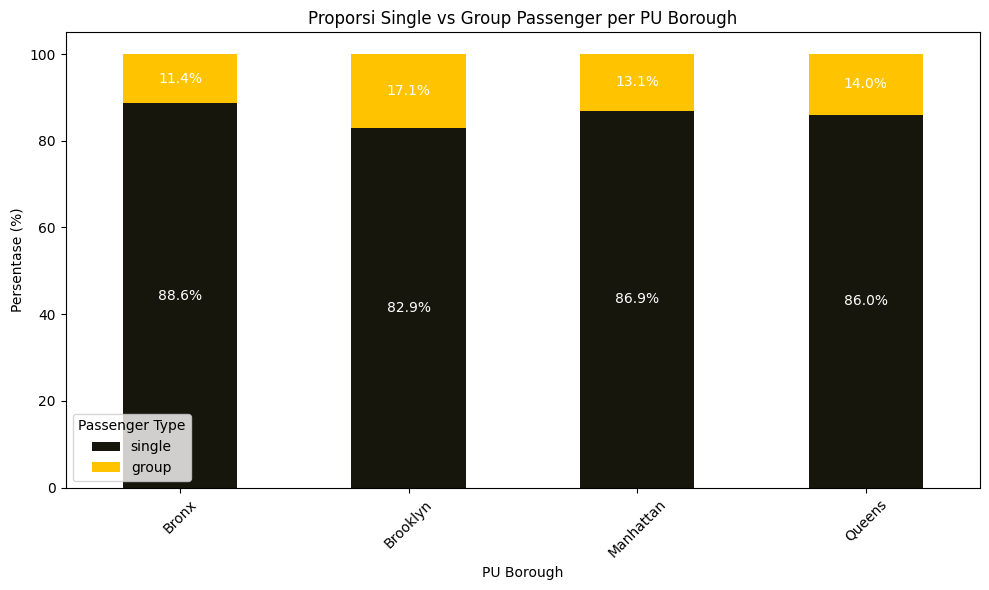

In [129]:
# Warna gradasi kuning
colors = ["#17160C", '#FFC300']  # light → darker yellow

ax = df_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=colors
)

plt.title('Proporsi Single vs Group Passenger per PU Borough')
plt.xlabel('PU Borough')
plt.ylabel('Persentase (%)')
plt.legend(title='Passenger Type')
plt.xticks(rotation=45)

# Label persentase
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', color='white')

plt.tight_layout()
plt.show()

# 2.11 Missed Out Analysis 2

In [130]:
df_filtered.columns

Index(['VendorID', 'lpep_pickup_datetime', 'pickup_day', 'pickup_flag_day',
       'lpep_dropoff_datetime', 'dropoff_day', 'dropoff_flag_day',
       'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'PU_Zone',
       'PU_borough', 'borough_flag', 'PU_service_zone', 'DOLocationID',
       'DO_Zone', 'DO_borough', 'DO_service_zone', 'passenger_count',
       'trip_distance', 'flag_distance', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'payment_type', 'trip_type', 'congestion_surcharge', 'RateCode_desc',
       'payment_type_desc', 'trip_type_desc', 'pu_lattitude_zone',
       'pu_longitude_zone', 'do_lattitude_zone', 'do_longitude_zone',
       'passenger_flag'],
      dtype='object')

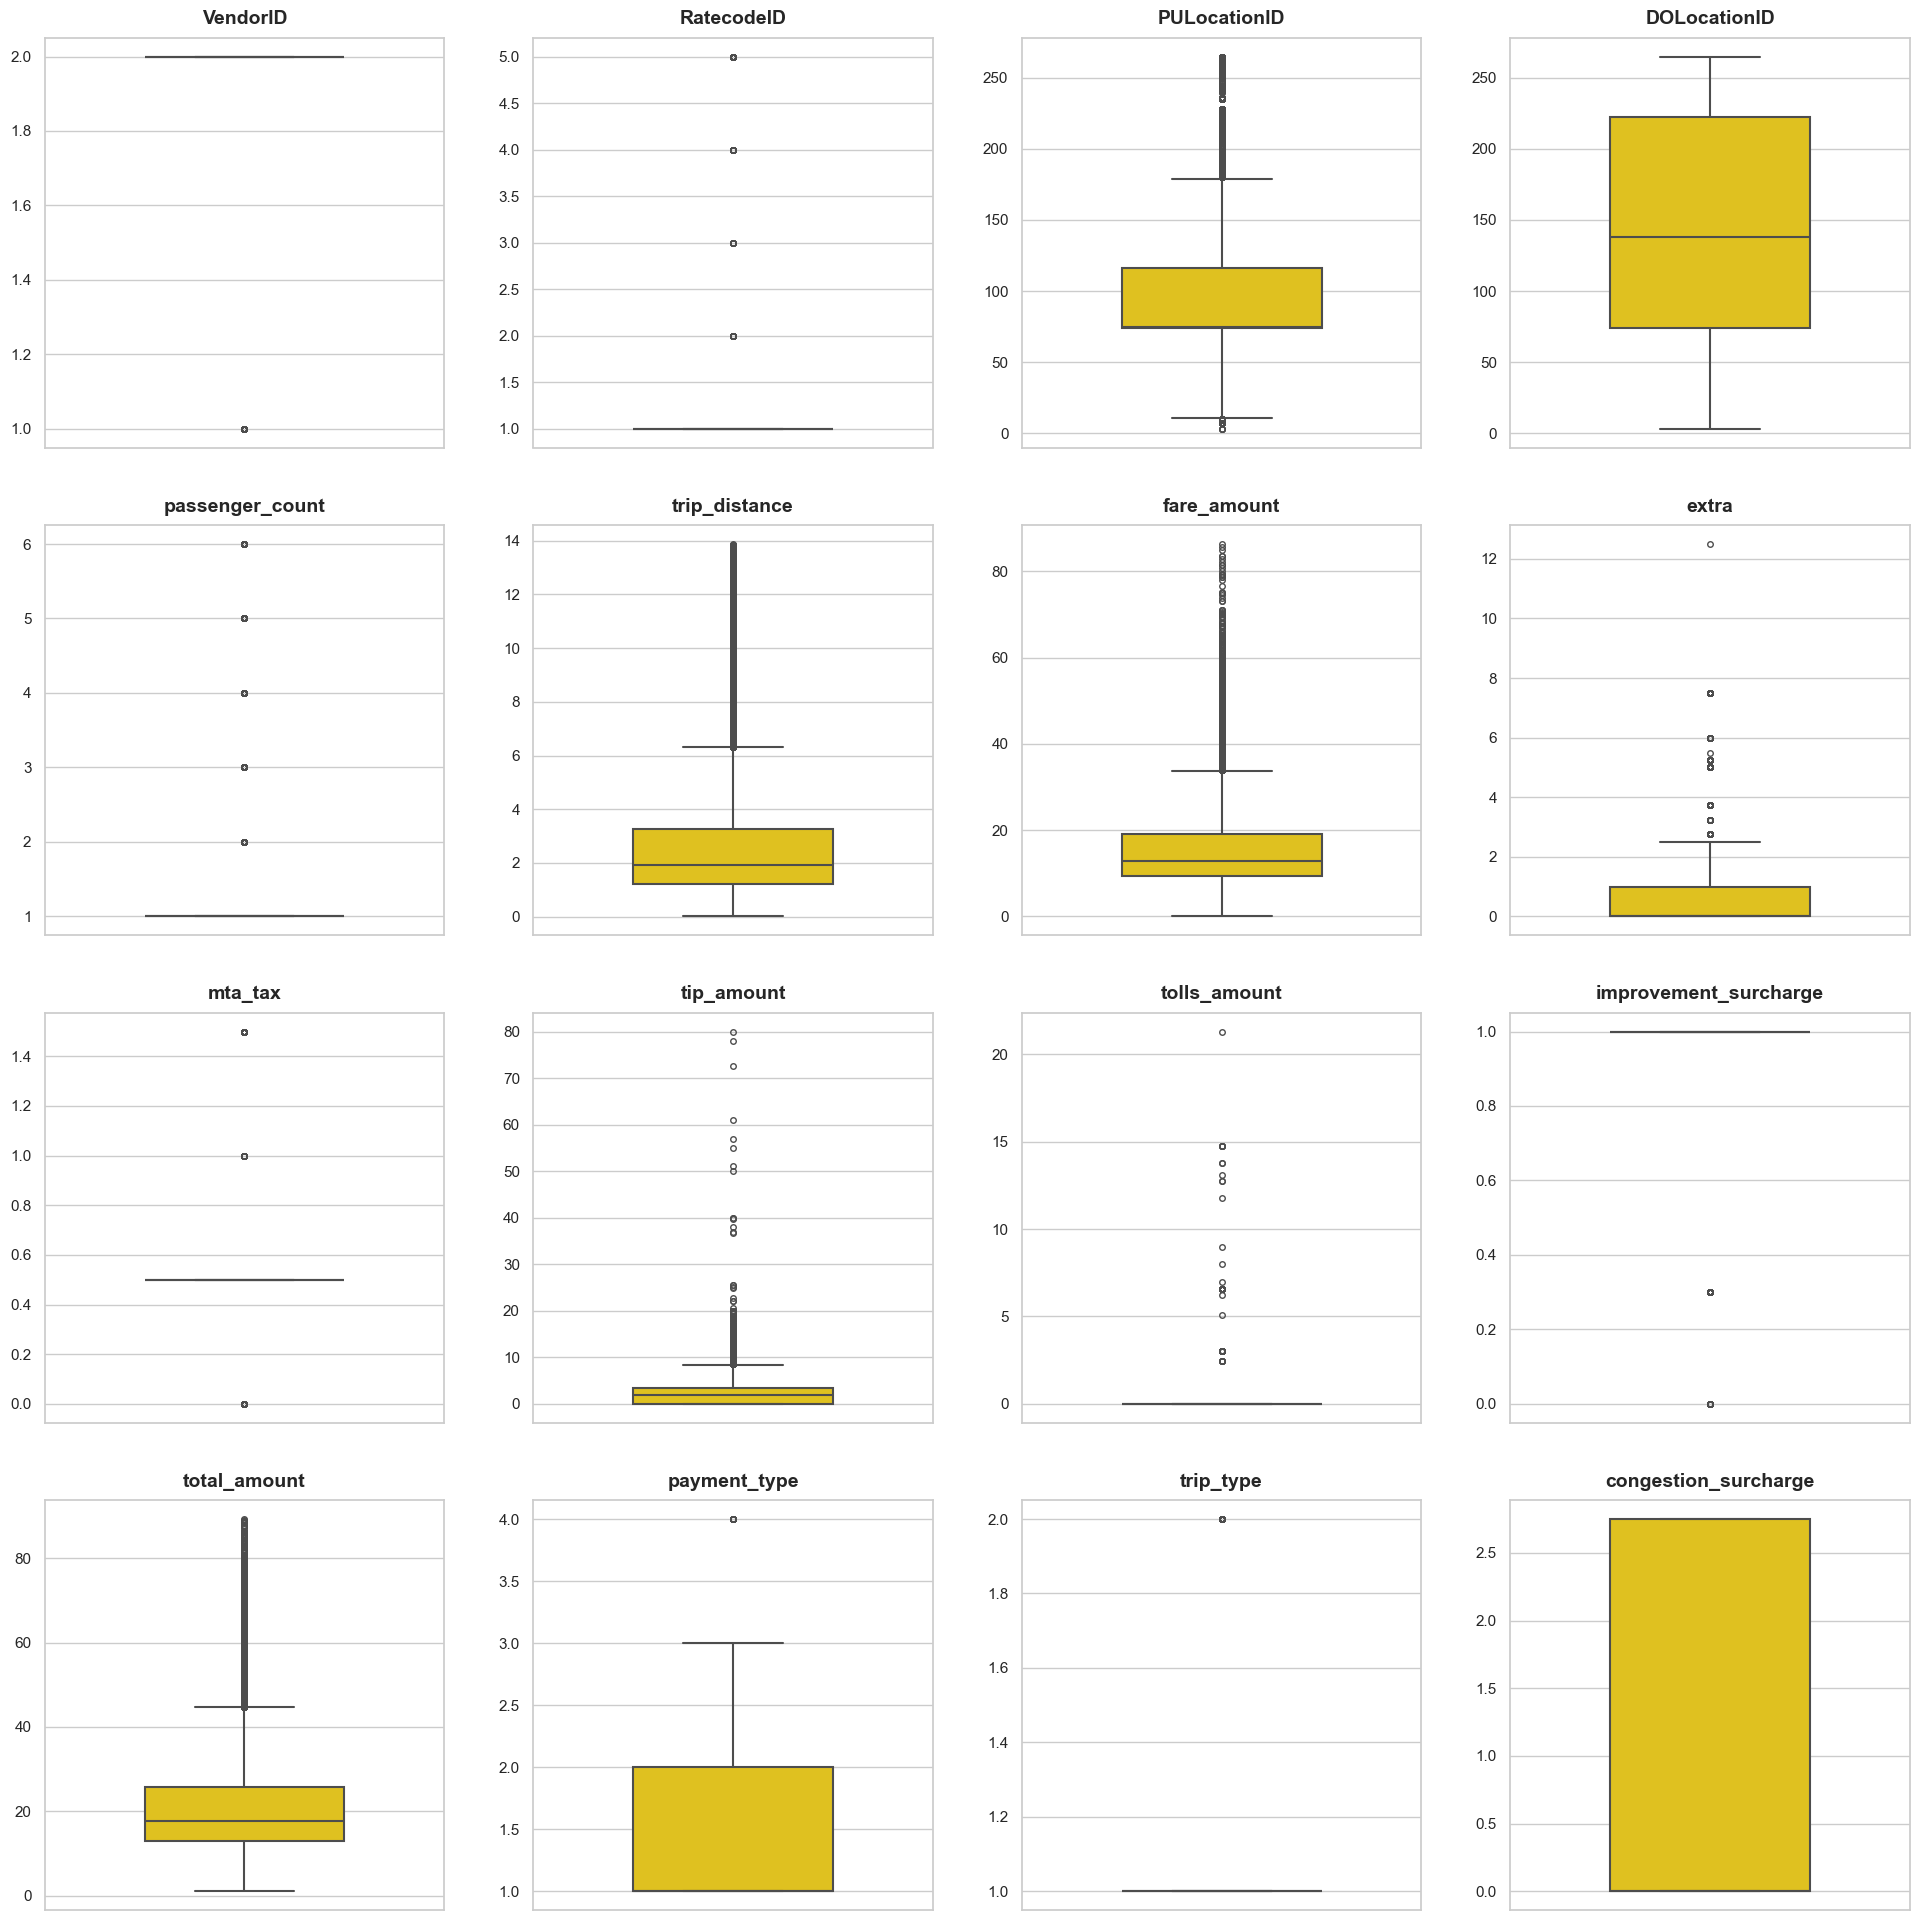

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Mengatur tema agar tampilan latar belakang lebih bersih (opsional)
sns.set_theme(style="whitegrid")

# 1. Memilih kolom yang bertipe data int64 atau float64
numerical_cols = df_filtered.select_dtypes(include=['int64', 'float64']).columns

# 2. Menentukan layout grid
n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)

# 3. Membuat kanvas
plt.figure(figsize=(20, n_rows * 5))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Kustomisasi boxplot: warna kuning cerah dengan garis tepi abu-abu gelap
    sns.boxplot(
        y=df_filtered[col], 
        color='#FFD700',      # Warna Gold yang menarik
        linewidth=1.5,        # Ketebalan garis box
        fliersize=4,          # Ukuran titik outlier
        width=0.5             # Lebar box
    )
    
    # Mempercantik Judul
    plt.title(f'{col}', fontsize=14, fontweight='bold', pad=10)
    plt.ylabel('') # Menghapus label Y agar tidak terlalu sesak
    
# Menyesuaikan tata letak agar tidak tumpang tindih
plt.tight_layout(pad=3.0)
plt.show()

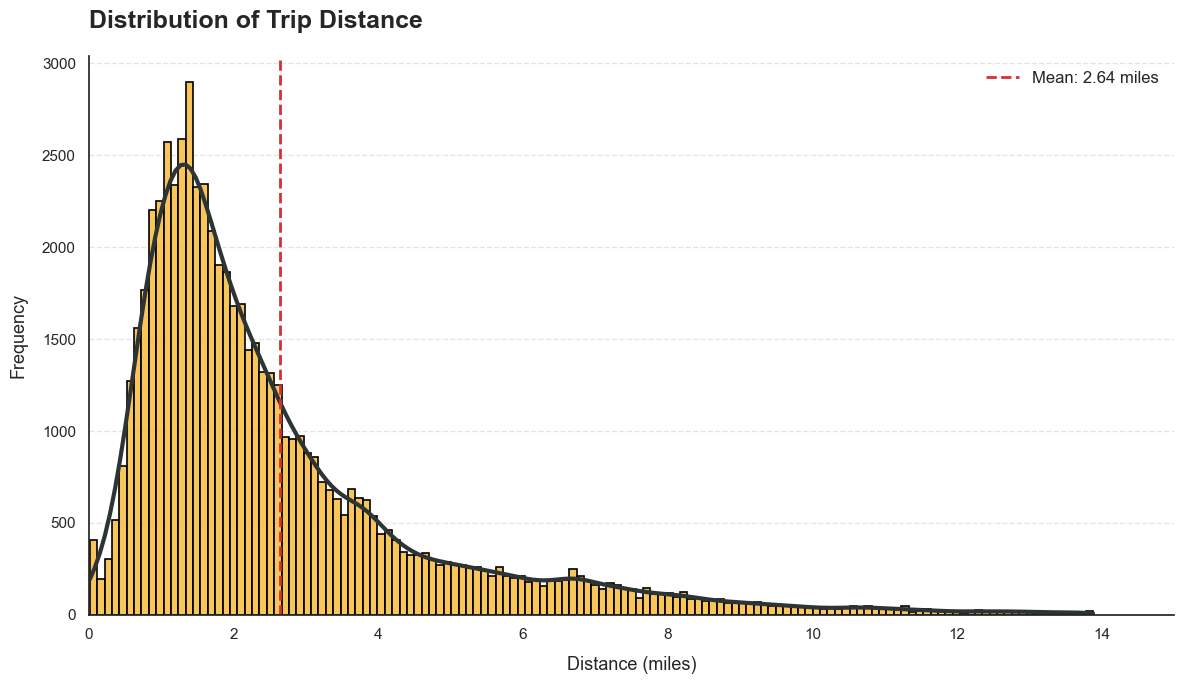

In [141]:
# Mengatur tema dasar
sns.set_theme(style="white")

# 1. Membuat figure
plt.figure(figsize=(12, 7))

# 2. Plot Histogram
# Warna #F7B731 atau #FFD700 adalah representasi kuning taxi yang ikonik
ax = sns.histplot(
    df_filtered['trip_distance'], 
    kde=True, 
    color='#F7B731', 
    edgecolor='black', 
    linewidth=1.2,
    alpha=0.8
)

# 3. Kustomisasi KDE (garis tren) agar lebih kontras
ax.lines[0].set_color('#2D3436') # Warna abu gelap/hitam untuk garis KDE
ax.lines[0].set_linewidth(3)

# 4. Tambahkan garis rata-rata (Mean)
mean_dist = df_filtered['trip_distance'].mean()
plt.axvline(mean_dist, color='#D63031', linestyle='--', linewidth=2, label=f'Mean: {mean_dist:.2f} miles')

# 5. Mempercantik tampilan (Styling)
plt.title('Distribution of Trip Distance', fontsize=18, fontweight='bold', pad=20, loc='left')
plt.xlabel('Distance (miles)', fontsize=13, labelpad=10)
plt.ylabel('Frequency', fontsize=13, labelpad=10)

# Membatasi sumbu X jika ada outlier yang terlalu jauh agar histogram tetap terbaca
# Misalnya kita fokus ke jarak 0-20 miles
plt.xlim(0, 15) 

# Menghapus garis bingkai atas dan kanan
sns.despine()

# Menambahkan grid hanya pada sumbu Y
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(frameon=False, fontsize=12)
plt.tight_layout()

plt.show()